# Generar Espectros

In [1]:
from __future__ import annotations

import gc
import os
import re
import tempfile
import warnings
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple, Union

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import pandexo.engine.justdoit as jdi
import pickle
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm

from tensorflow import keras


def suppress_deprecation_warnings() -> None:
    """Suppress deprecation warnings (use carefully in notebooks)."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


# ---- Matplotlib style (kept close to yours, just centralized) ----
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = [
    "STIXGeneral",
    "DejaVu Serif",
    "Times New Roman",
    "CMU Serif",
    "Liberation Serif",
]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "normal"
mpl.rcParams["axes.titlepad"] = 10
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.titleweight"] = "normal"

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

EPS_RANGE = 1e-12


In [2]:
waves = np.loadtxt("waves.txt", dtype=float)
n_points = int(waves.size)

# Wavenumber grid (cm^-1) as in your pipeline
wn_grid = np.sort(10000.0 / waves)

In [3]:
def apply_contaminations_from_files(
    contamination_files: Sequence[str],
    df: pd.DataFrame,
    n_points: int,
    include_no_contam: bool = False,
) -> pd.DataFrame:
    """
    Apply multiplicative stellar contamination vectors from files to the last n_points columns.

    Expected filename pattern:
        ...fspot<val>_ffac<val>.txt
    Example:
        epsilon_T3500_fspot0.000_ffac0.000.txt

    Notes
    -----
    - The last `n_points` columns are treated as the spectrum.
    - Adds 'f_spot' and 'f_fac' columns.
    - Attaches convenience attributes:
        df_final.data   -> last n_points columns
        df_final.params -> all other columns
    """
    df_list: list[pd.DataFrame] = []

    if include_no_contam:
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        cols = ["f_spot", "f_fac"] + [
            c for c in df_no_contam.columns if c not in ("f_spot", "f_fac")
        ]
        df_list.append(df_no_contam[cols])

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"Contamination file not found: {file_path}")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if match is None:
            raise ValueError(f"Filename does not match pattern: {filename}")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        contamination_data = np.loadtxt(file_path, ndmin=2)
        if contamination_data.shape[1] >= 2:
            contam_values = contamination_data[:, 1]
        else:
            contam_values = contamination_data.flatten()

        if contam_values.size != n_points:
            raise ValueError(
                f"Contamination length mismatch in '{filename}': "
                f"{contam_values.size} vs n_points={n_points}"
            )

        # Keep your orientation choice
        contam_values = contam_values[::-1]

        df_contam = df.copy()
        spec_cols = df_contam.columns[-n_points:]
        df_contam[spec_cols] = df_contam[spec_cols].multiply(contam_values, axis=1)

        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac

        cols = ["f_spot", "f_fac"] + [
            c for c in df_contam.columns if c not in ("f_spot", "f_fac")
        ]
        df_list.append(df_contam[cols])

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]
    return df_final


def mult_df(df: pd.DataFrame, n_points: int, n_mult: int) -> pd.DataFrame:
    """
    Repeat a DataFrame (n_mult + 1) times, tagging f_spot=f_fac=0.0 for each block.

    This is used to build a clean counterpart with the SAME number of base rows as
    the contaminated dataset (one block per contamination file).
    """
    blocks: list[pd.DataFrame] = []
    for _ in range(n_mult + 1):
        block = df.copy()
        block["f_spot"] = 0.0
        block["f_fac"] = 0.0
        cols = ["f_spot", "f_fac"] + [c for c in block.columns if c not in ("f_spot", "f_fac")]
        blocks.append(block[cols])

    df_final = pd.concat(blocks, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]
    return df_final

## Base dataset and flat baseline

In [4]:
k2_18b = joblib.load("specs/k2-18b_data.joblib")

# Replace NaNs for these columns as in your pipeline
cols_fill = ["atm CO2", "atm CH4", "atm H2O", "atm NH3"]
k2_18b[cols_fill] = k2_18b[cols_fill].fillna(0)

# Flat spectrum selection (kept consistent with your filtering)
flat = (
    k2_18b[
        (k2_18b["atm CO2"] == -10)
        & (k2_18b["atm CH4"] == 0)
        & (k2_18b["atm H2O"] == 0)
        & (k2_18b["atm NH3"] == 0)
    ]
    .iloc[0:1]
    .copy()
)

DEPTH_K218 = 0.0023243496509944973
flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = DEPTH_K218

flat.data = flat.iloc[:, -n_points:]
flat.params = flat.iloc[:, :-n_points]

# Contamination files
contamination_files = sorted(
    Path("TLS").glob("epsilon_T3500_fspot*_ffac*.txt")
)
contamination_files = [str(p) for p in contamination_files]

print(f"Found {len(contamination_files)} contamination files.")

suppress_deprecation_warnings()

k2_18b_contam = apply_contaminations_from_files(
    contamination_files=contamination_files,
    df=k2_18b,
    n_points=n_points,
)
flat_contam = apply_contaminations_from_files(
    contamination_files=contamination_files,
    df=flat,
    n_points=n_points,
)

# Clean blocks: one block per contamination file (size-aligned with contam)
n_mult = len(contamination_files) - 1
k2_18b_mult = mult_df(k2_18b, n_points=n_points, n_mult=n_mult)
flat_mult = mult_df(flat, n_points=n_points, n_mult=n_mult)

print("Shapes:")
print("  k2_18b_contam:", k2_18b_contam.shape)
print("  k2_18b_mult: ", k2_18b_mult.shape)
print("  flat_contam: ", flat_contam.shape)
print("  flat_mult:   ", flat_mult.shape)

assert k2_18b_contam.data.shape[1] == n_points
assert k2_18b_mult.data.shape[1] == n_points

C:\Users\User\AppData\Local\Temp\ipykernel_43332\4027928313.py:23: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.data = flat.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\4027928313.py:24: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.params = flat.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:71: PerformanceWarning: 

Found 16 contamination files.


C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

Shapes:
  k2_18b_contam: (352800, 409)
  k2_18b_mult:  (352800, 409)
  flat_contam:  (16, 409)
  flat_mult:    (16, 409)


C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:100: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:101: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:100: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:101: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://panda

## JWST / PandExo instrumental noise model

In [5]:
def generate_df_with_noise_std(
    df: pd.DataFrame,
    n_repeat: int,
    noise_std: Union[float, Sequence[float], np.ndarray, pd.Series],
    seed: Optional[int] = None,
) -> pd.DataFrame:
    """
    Replicate each spectrum n_repeat times and add Gaussian noise.

    noise_std can be:
    - float: same sigma for all entries
    - 1D array length N_spectra: one sigma per spectrum (broadcast across wavelength)
    - 1D array length N_wavelengths: one sigma per wavelength (same for all spectra)

    Returns a DataFrame with attached attributes:
      df_final.data   -> spectra block
      df_final.params -> params block (with inserted noise_std, n_repeat)
    """
    if not hasattr(df, "params") or not hasattr(df, "data"):
        raise ValueError("Input df must have .params and .data attributes.")

    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")

    if seed is not None:
        if not isinstance(seed, int) or seed < 0:
            raise ValueError("seed must be a non-negative integer.")
        np.random.seed(seed)

    df_params = df.params
    df_spectra = df.data
    n_spec, n_wl = df_spectra.shape

    spectra_rep = np.repeat(df_spectra.values, n_repeat, axis=0)

    # Expand noise_std into (n_spec*n_repeat, n_wl)
    if isinstance(noise_std, (int, float)):
        if float(noise_std) < 0:
            raise ValueError("noise_std must be non-negative.")
        sigma = np.full_like(spectra_rep, float(noise_std), dtype=float)
        noise_std_for_params = np.full(n_spec * n_repeat, float(noise_std), dtype=float)

    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if noise_array.ndim != 1:
            raise ValueError("If array-like, noise_std must be 1D.")
        if np.any(noise_array < 0):
            raise ValueError("All noise_std values must be non-negative.")

        if noise_array.size == n_spec:
            base = np.repeat(noise_array[:, None], n_repeat, axis=0)  # (n_spec*n_repeat, 1)
            sigma = np.tile(base, (1, n_wl))                          # (n_spec*n_repeat, n_wl)
            noise_std_for_params = np.repeat(noise_array, n_repeat)

        elif noise_array.size == n_wl:
            sigma = np.tile(noise_array[None, :], (n_spec * n_repeat, 1))
            noise_std_for_params = np.full(n_spec * n_repeat, float(noise_array.mean()), dtype=float)

        else:
            raise ValueError("noise_std length must be N_spectra or N_wavelengths.")

    noisy = spectra_rep + np.random.normal(loc=0.0, scale=sigma, size=spectra_rep.shape)

    params_rep = np.repeat(df_params.values, n_repeat, axis=0)
    df_params_rep = pd.DataFrame(params_rep, columns=df_params.columns)
    df_params_rep.insert(0, "noise_std", noise_std_for_params)
    df_params_rep.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [df_params_rep.reset_index(drop=True), pd.DataFrame(noisy, columns=df_spectra.columns)],
        axis=1,
    )
    df_final.data = df_final.iloc[:, -n_wl:]
    df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
    return df_final

In [6]:
def generate_df_with_noise_std(
    df: pd.DataFrame,
    n_repeat: int,
    noise_std: Union[float, Sequence[float], np.ndarray, pd.Series],
    seed: Optional[int] = None,
) -> pd.DataFrame:
    """
    Replicate each spectrum n_repeat times and add Gaussian noise.

    noise_std can be:
    - float: same sigma for all entries
    - 1D array length N_spectra: one sigma per spectrum (broadcast across wavelength)
    - 1D array length N_wavelengths: one sigma per wavelength (same for all spectra)

    Returns a DataFrame with attached attributes:
      df_final.data   -> spectra block
      df_final.params -> params block (with inserted noise_std, n_repeat)
    """
    if not hasattr(df, "params") or not hasattr(df, "data"):
        raise ValueError("Input df must have .params and .data attributes.")

    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")

    if seed is not None:
        if not isinstance(seed, int) or seed < 0:
            raise ValueError("seed must be a non-negative integer.")
        np.random.seed(seed)

    df_params = df.params
    df_spectra = df.data
    n_spec, n_wl = df_spectra.shape

    spectra_rep = np.repeat(df_spectra.values, n_repeat, axis=0)

    # Expand noise_std into (n_spec*n_repeat, n_wl)
    if isinstance(noise_std, (int, float)):
        if float(noise_std) < 0:
            raise ValueError("noise_std must be non-negative.")
        sigma = np.full_like(spectra_rep, float(noise_std), dtype=float)
        noise_std_for_params = np.full(n_spec * n_repeat, float(noise_std), dtype=float)

    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if noise_array.ndim != 1:
            raise ValueError("If array-like, noise_std must be 1D.")
        if np.any(noise_array < 0):
            raise ValueError("All noise_std values must be non-negative.")

        if noise_array.size == n_spec:
            base = np.repeat(noise_array[:, None], n_repeat, axis=0)  # (n_spec*n_repeat, 1)
            sigma = np.tile(base, (1, n_wl))                          # (n_spec*n_repeat, n_wl)
            noise_std_for_params = np.repeat(noise_array, n_repeat)

        elif noise_array.size == n_wl:
            sigma = np.tile(noise_array[None, :], (n_spec * n_repeat, 1))
            noise_std_for_params = np.full(n_spec * n_repeat, float(noise_array.mean()), dtype=float)

        else:
            raise ValueError("noise_std length must be N_spectra or N_wavelengths.")

    noisy = spectra_rep + np.random.normal(loc=0.0, scale=sigma, size=spectra_rep.shape)

    params_rep = np.repeat(df_params.values, n_repeat, axis=0)
    df_params_rep = pd.DataFrame(params_rep, columns=df_params.columns)
    df_params_rep.insert(0, "noise_std", noise_std_for_params)
    df_params_rep.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [df_params_rep.reset_index(drop=True), pd.DataFrame(noisy, columns=df_spectra.columns)],
        axis=1,
    )
    df_final.data = df_final.iloc[:, -n_wl:]
    df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
    return df_final


In [7]:
MAG_J_K218 = 9.763
TSTAR_K218 = 3500.0
LOGG_K218 = 4.6
MET_K218 = 0.0
TTRANS_H_K218 = 2.682


def get_k218_prism_noise_flat(
    wl_grid_um: Union[np.ndarray, Sequence[float]],
    depth_rp2_rs2: float = DEPTH_K218,
    n_transits: int = 10,
    t_star: float = TSTAR_K218,
    transit_duration_hours: float = TTRANS_H_K218,
    plot: bool = False,
    cut_first: int = 20,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return an instrumental noise vector for K2-18 with JWST/NIRSpec Prism using PandExo.

    The input spectrum is flat in (Rp/Rs)^2.

    Returns
    -------
    waves_trim : np.ndarray
        PandExo wavelength grid (um), after trimming.
    errors_trim : np.ndarray
        PandExo error_w_floor array, after trimming.
    """
    wl_grid_um = np.asarray(wl_grid_um, dtype=float)
    depth_arr = np.full_like(wl_grid_um, depth_rp2_rs2, dtype=float)

    tmp_path: Optional[str] = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            np.savetxt(tmp, np.column_stack([wl_grid_um, depth_arr]))

        exo = jdi.load_exo_dict()

        transit_duration_sec = float(transit_duration_hours) * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        exo["observation"].update(
            {
                "sat_level": 80,
                "sat_unit": "%",
                "baseline_unit": "total",
                "baseline": baseline_sec,
                "noise_floor": 0,
                "noccultations": int(n_transits),
            }
        )

        exo["star"].update(
            {
                "type": "phoenix",
                "mag": MAG_J_K218,
                "ref_wave": 1.25,
                "temp": float(t_star),
                "metal": MET_K218,
                "logg": LOGG_K218,
            }
        )

        exo["planet"].update(
            {
                "type": "user",
                "w_unit": "um",
                "f_unit": "rp^2/r*^2",
                "transit_duration": transit_duration_sec,
                "td_unit": "s",
                "exopath": tmp_path,
            }
        )

        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({"subarray": "sub512", "ngroup": 6})

        results = jdi.run_pandexo(exo, inst)

        waves_full = np.asarray(results["FinalSpectrum"]["wave"], dtype=float)
        flux_full = np.asarray(results["FinalSpectrum"]["spectrum"], dtype=float)
        errors_full = np.asarray(results["FinalSpectrum"]["error_w_floor"], dtype=float)

        if cut_first > 0:
            waves_trim = waves_full[cut_first:]
            flux_trim = flux_full[cut_first:]
            errors_trim = errors_full[cut_first:]
        else:
            waves_trim = waves_full
            flux_trim = flux_full
            errors_trim = errors_full

        if plot:
            plt.figure(figsize=(8, 4))
            plt.errorbar(
                waves_trim,
                flux_trim,
                yerr=errors_trim,
                fmt="o",
                ms=4,
                elinewidth=1,
                capsize=2,
            )
            plt.xlabel("Wavelength (μm)")
            plt.ylabel("Transit depth (Rp/R*)²")
            plt.title(f"PandExo K2-18 — {n_transits} transits, T*={t_star:.0f} K")
            plt.tight_layout()
            plt.show()

    finally:
        if tmp_path is not None and os.path.exists(tmp_path):
            os.remove(tmp_path)

    return waves_trim, errors_trim


def resample_sigma_to_target_grid(
    waves_src: np.ndarray,
    sigma_src: np.ndarray,
    waves_tgt: np.ndarray,
) -> np.ndarray:
    """
    Interpolate sigma(wavelength) from waves_src to waves_tgt.

    This is the safest way to enforce sigma length == n_points when grids mismatch.
    """
    waves_src = np.asarray(waves_src, dtype=float)
    sigma_src = np.asarray(sigma_src, dtype=float)
    waves_tgt = np.asarray(waves_tgt, dtype=float)

    # PandExo is usually increasing; enforce sorted interpolation
    order = np.argsort(waves_src)
    waves_src = waves_src[order]
    sigma_src = sigma_src[order]

    return np.interp(waves_tgt, waves_src, sigma_src).astype(np.float32)


## Autoencoder and $\chi^2$ metrics

In [8]:
autoencoder = keras.models.load_model("AE.keras")


def chi2(x: np.ndarray, x_recon: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """
    Compute $\chi^2$ per sample: $\sum_i ((x_i - \hat{x}_i) / \sigma_i)^2$.
    """
    return np.sum(((x - x_recon) / sigma) ** 2, axis=1)


def chi2_reduced(
    x: np.ndarray,
    x_recon: np.ndarray,
    sigma: np.ndarray,
    p: int = 0,
) -> np.ndarray:
    """
    Compute reduced $\chi^2$ per sample: $\chi^2 / (N - p)$.
    """
    chi2_vals = chi2(x, x_recon, sigma)
    n = x.shape[1]
    dof = max(1, n - int(p))
    return chi2_vals / dof


## Uncertainty Quantification (UQ)

We model three uncertainty components:

1. **Aleatoric uncertainty** (fixed rule):
   $$
   \sigma_{\mathrm{ale}} = 0.5 \, \sigma_{\mathrm{inst}}
   $$

2. **Epistemic uncertainty** via **MC Dropout**:
   multiple stochastic forward passes through the autoencoder.

3. **Total uncertainty** combined in quadrature:
   $$
   \sigma_{\mathrm{total}} = \sqrt{\sigma_{\mathrm{ale}}^2 + \sigma_{\mathrm{epi}}^2 }
   $$.


In [9]:
def calc_aleatoric_half_instrumental(
    sigma_inst: Union[np.ndarray, float],
    shape: Tuple[int, int],
    dtype: np.dtype = np.float32,
) -> np.ndarray:
    """
    Aleatoric uncertainty defined as exactly half the instrumental noise:

        sigma_ale = 0.5 * sigma_inst

    sigma_inst can be:
      - scalar
      - (D,) vector
      - (N, D) matrix
    """
    n, d = shape
    factor = 0.5

    if np.ndim(sigma_inst) == 0:
        sig = np.full((n, d), float(sigma_inst), dtype=dtype)
    else:
        s = np.asarray(sigma_inst, dtype=dtype)
        if s.ndim == 1:
            if s.shape[0] != d:
                raise ValueError(f"sigma_inst has len={s.shape[0]} but D={d}")
            sig = np.tile(s[None, :], (n, 1))
        elif s.ndim == 2:
            if s.shape != (n, d):
                raise ValueError(f"sigma_inst has shape={s.shape}, expected (N,D)=({n},{d})")
            sig = s
        else:
            raise ValueError(f"Unsupported sigma_inst ndim: {s.ndim}")

    return (sig * factor).astype(dtype, copy=False)


def mc_dropout_sigma_anchor_clean(
    autoencoder_model,
    x_noisy_raw: pd.DataFrame,
    x_clean_raw: pd.DataFrame,
    t_passes: int = 100,
    batch_size: int = 50_000,
    dtype: np.dtype = np.float32,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Epistemic uncertainty via MC Dropout, processed in batches to avoid OOM.

    Workflow (per batch)
    --------------------
    1) Normalize noisy per-sample (min-max).
    2) Run T stochastic forward passes (training=True).
    3) De-normalize using CLEAN (anchor) min/max of the corresponding samples.
    4) Return mean and std across passes.

    Returns
    -------
    final_mean : (N, D) ndarray
    final_std  : (N, D) ndarray
    """
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype)
    x_clean = np.asarray(x_clean_raw.values, dtype=dtype)

    n, d = x_noisy.shape
    final_mean = np.zeros((n, d), dtype=dtype)
    final_std = np.zeros((n, d), dtype=dtype)

    num_batches = int(np.ceil(n / batch_size))
    print(f"MC Dropout: N={n}, D={d}, batches={num_batches}, batch_size={batch_size}")

    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, n)

        noisy_b = x_noisy[start:end]
        clean_b = x_clean[start:end]

        # --- normalize noisy (min-max per row) ---
        n_min = noisy_b.min(axis=1, keepdims=True)
        n_max = noisy_b.max(axis=1, keepdims=True)
        n_rng = n_max - n_min
        n_rng_safe = np.where(n_rng <= EPS_RANGE, 1.0, n_rng)

        noisy_norm = (noisy_b - n_min) / n_rng_safe
        flat_mask = (n_rng[:, 0] <= EPS_RANGE)
        if np.any(flat_mask):
            noisy_norm[flat_mask] = 0.0

        # --- clean anchor stats for de-normalization ---
        c_min = clean_b.min(axis=1, keepdims=True)
        c_max = clean_b.max(axis=1, keepdims=True)
        c_rng = c_max - c_min
        c_rng_safe = np.where(c_rng <= EPS_RANGE, 1.0, c_rng)

        # --- MC passes ---
        preds = []
        for _ in range(int(t_passes)):
            pred = autoencoder_model(noisy_norm, training=True).numpy().astype(dtype, copy=False)
            preds.append(pred)

        preds = np.stack(preds, axis=0)  # (T, nb, D)

        # --- de-normalize using clean anchor ---
        preds_denorm = preds * c_rng_safe[None, :, :] + c_min[None, :, :]

        mean_b = preds_denorm.mean(axis=0).astype(dtype, copy=False)
        std_b = preds_denorm.std(axis=0, ddof=1).astype(dtype, copy=False)

        final_mean[start:end] = mean_b
        final_std[start:end] = std_b

        del preds, preds_denorm, noisy_norm, noisy_b, clean_b
        if b % 10 == 0:
            print(f"  batch {b+1}/{num_batches} done")

    return final_mean, final_std


def combine_uncertainties(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    sigma_sys: Optional[np.ndarray] = None,
    floor: float = 0.0,
    dtype: np.dtype = np.float32,
) -> np.ndarray:
    """
    Combine uncertainties in quadrature:

        sigma_total = sqrt(sigma_ale^2 + sigma_epi^2 + sigma_sys^2)

    A small floor can be applied to prevent division by zero in χ².
    """
    sig2 = np.asarray(sigma_ale, dtype=dtype) ** 2
    if sigma_epi is not None:
        sig2 = sig2 + (np.asarray(sigma_epi, dtype=dtype) ** 2)
    if sigma_sys is not None:
        sig2 = sig2 + (np.asarray(sigma_sys, dtype=dtype) ** 2)

    sigma_total = np.sqrt(sig2).astype(dtype, copy=False)
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor).astype(dtype, copy=False)
    return sigma_total


def sigma_comparison_summary(
    sigma_inst: np.ndarray,
    sigma_ale: np.ndarray,
    sigma_epi: np.ndarray,
    sigma_total: np.ndarray,
) -> Dict[str, float]:
    """
    Small numeric summary to sanity-check relative magnitudes.
    """
    n, d = sigma_ale.shape
    sigma_inst = np.asarray(sigma_inst)

    if sigma_inst.ndim == 1:
        sigma_inst_nd = np.broadcast_to(sigma_inst[None, :], (n, d))
    elif sigma_inst.ndim == 2:
        sigma_inst_nd = sigma_inst
    else:
        raise ValueError("sigma_inst must be (D,) or (N,D).")

    def _flat(a: np.ndarray) -> np.ndarray:
        arr = np.asarray(a, dtype=np.float64).ravel()
        return arr[np.isfinite(arr)]

    def _med_ratio(a: np.ndarray, b: np.ndarray) -> float:
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m == 0:
            return float("nan")
        return float(np.median(a1[:m] / np.clip(b1[:m], 1e-12, np.inf)))

    def _corr(a: np.ndarray, b: np.ndarray) -> float:
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m < 2:
            return float("nan")
        return float(np.corrcoef(a1[:m], b1[:m])[0, 1])

    return {
        "med_ratio_ale_vs_inst": _med_ratio(sigma_ale, sigma_inst_nd),
        "med_ratio_epi_vs_inst": _med_ratio(sigma_epi, sigma_inst_nd),
        "med_ratio_tot_vs_inst": _med_ratio(sigma_total, sigma_inst_nd),
        "corr_epi_vs_inst": _corr(sigma_epi, sigma_inst_nd),
    }


# Experiment A — Single transit count

This experiment runs the full pipeline for a fixed number of transits `T_TRANSITS`:

1. Compute $\sigma_{\mathrm{inst}}$ with PandExo.
2. Build:
   - `df_noisy` (contaminated + noisy)
   - `df_clean` (clean targets)
3. Run UQ:
   - $\sigma_{\mathrm{ale}}$
   - $\sigma_{\mathrm{epi}}$ (MC Dropout)
   - $\sigma_{\mathrm{total}}$
4. Compute $\chi_r^2$ metrics for:
   - observed vs reconstructed (using $\sigma_{\mathrm{inst}}$)
   - clean vs reconstructed (using $\sigma_{\mathrm{total}}$)

Memory cleanup is performed after the run to reduce RAM usage.


In [ ]:
T_TRANSITS = 1
NREP_PLANET = 3
NREP_FLAT = 300
T_PASSES_DROPOUT = 50
EPS_SIGMA = 1e-12

print(f"Computing PandExo noise for T={T_TRANSITS}...")

wl_grid_sim = np.linspace(0.6, 5.3, 1000)
waves_pdx, sigma_inst_raw = get_k218_prism_noise_flat(
    wl_grid_um=wl_grid_sim,
    n_transits=T_TRANSITS,
    t_star=TSTAR_K218,
    plot=True,
    cut_first=18,
)

# Your convention: reverse if you want (kept), but then resample safely to `waves`
sigma_inst_raw = sigma_inst_raw[::-1]
waves_pdx = waves_pdx[::-1]

sigma_inst = resample_sigma_to_target_grid(
    waves_src=waves_pdx,
    sigma_src=sigma_inst_raw,
    waves_tgt=waves,
)

assert sigma_inst.shape[0] == n_points
print("Noise aligned to waves grid:", sigma_inst.shape)

# Build noisy/clean datasets (same ordering -> index-consistent)
df_noisy = pd.concat(
    [
        generate_df_with_noise_std(k2_18b_contam, NREP_PLANET, sigma_inst),
        generate_df_with_noise_std(flat_contam, NREP_FLAT, sigma_inst),
    ],
    ignore_index=True,
)

df_clean = pd.concat(
    [
        generate_df_with_noise_std(k2_18b_mult, NREP_PLANET, 0.0),
        generate_df_with_noise_std(flat_mult, NREP_FLAT, 0.0),
    ],
    ignore_index=True,
)

X_noisy_raw = df_noisy.iloc[:, -n_points:]
X_clean_raw = df_clean.iloc[:, -n_points:]

print("Running UQ...")
sigma_ale = calc_aleatoric_half_instrumental(sigma_inst, X_noisy_raw.shape)
recon_mean, sigma_epi = mc_dropout_sigma_anchor_clean(
    autoencoder_model=autoencoder,
    x_noisy_raw=X_noisy_raw,
    x_clean_raw=X_clean_raw,
    t_passes=T_PASSES_DROPOUT,
)

sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)

chi2r_obs = chi2_reduced(X_noisy_raw.values, recon_mean, sigma_inst, p=0)
chi2r_clean = chi2_reduced(X_clean_raw.values, recon_mean, np.clip(sigma_total, EPS_SIGMA, np.inf), p=0)

print(f"\nResults (T={T_TRANSITS}):")
print(f"  mean chi2_r (Obs vs Recon, sigma_inst):   {np.mean(chi2r_obs):.4f}")
print(f"  mean chi2_r (Clean vs Recon, sigma_total): {np.mean(chi2r_clean):.4f}")

# Keep these for downstream plot cells
errors = sigma_inst
waves_i = waves[::-1]

del df_noisy, df_clean
gc.collect()

In [ ]:
def plot_uncertainty_summary(
    waves_um: np.ndarray,
    sigma_inst_1d: np.ndarray,
    sigma_epi_nd: np.ndarray,
    out_png: Path,
) -> None:
    """Plot median epistemic vs instrumental uncertainties."""
    waves_um = np.asarray(waves_um)
    sigma_inst_1d = np.asarray(sigma_inst_1d)
    sigma_epi_nd = np.asarray(sigma_epi_nd)

    sigma_epi_med = np.median(sigma_epi_nd, axis=0)

    plt.figure(figsize=(10, 8))
    plt.plot(waves_um[::-1], sigma_inst_1d * 1e6, label="Instrumental", lw=2.4, color="#2A9D8F")
    plt.plot(waves_um[::-1], sigma_epi_med * 1e6, label="Epistemic", lw=2.4, color="#264653")
    plt.xlabel("Wavelength [μm]")
    plt.ylabel(r"$\bar{\sigma}$ $(R_p/R_s)^2$ [ppm]")
    plt.title("Mean uncertainties", fontsize=22)
    plt.legend()
    plt.grid(True)
    plt.savefig(out_png, dpi=300)
    plt.show()


plot_uncertainty_summary(
    waves_um=waves,
    sigma_inst_1d=errors,
    sigma_epi_nd=sigma_epi,
    out_png=PLOTS_DIR / "DAE_uncertainties.png",
)


def create_plot(uncertainty_type: str) -> None:
    """
    Plot three representative cases (flat, high contamination, baseline) with:
    - clean spectrum
    - noisy spectrum with sigma_inst
    - reconstructed spectrum with sigma_inst or sigma_total
    - residual panels

    uncertainty_type: "instrumental" or "total"
    """
    y_recon_all = recon_mean
    sigma_total_all = sigma_total
    y_clean_all = X_clean_raw.values
    y_noisy_all = X_noisy_raw.values
    sigma_inst_1d = errors
    w = waves_i

    n_rep_p = NREP_PLANET
    n_rep_f = NREP_FLAT
    len_k2_original = len(k2_18b_contam)
    offset_flats = len_k2_original * n_rep_p

    # Candidate indices (base rows, before n_repeat expansion)
    cand_flat = flat_contam[(flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)].index
    cand_high = k2_18b_contam[(k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)].index
    cand_no = k2_18b_contam[(k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)].index

    idx_flat = int(np.random.choice(cand_flat))
    idx_high = int(np.random.choice(cand_high))
    idx_no = int(np.random.choice(cand_no))

    idx_list_orig = [idx_flat, idx_high, idx_no]
    is_flat_mask = [True, False, False]

    colors = {
        "original": "#264653",
        "reconstructed": "#2A9D8F",
        "noisy_points": "#F4A261",
        "fill_uq_resid": "#cccccc80",
    }

    custom_titles = [
        "Flat signal — low stellar contamination",
        "Hycean Atmosphere — high stellar contamination",
        "Hycean Atmosphere — contamination-free baseline",
    ]

    spacer = 2.5
    n_groups = len(idx_list_orig)
    height_ratios = [
        val
        for i in range(n_groups)
        for val in ([2, 4, 1.5] + ([spacer] if i < n_groups - 1 else []))
    ]

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        # Map base-row index -> final expanded index
        if is_flat:
            start_pos = offset_flats + (idx_orig * n_rep_f)
            final_idx = start_pos + int(np.random.randint(0, n_rep_f))
        else:
            start_pos = idx_orig * n_rep_p
            final_idx = start_pos + int(np.random.randint(0, n_rep_p))

        base = 4 * i
        ax_orig = fig.add_subplot(gs[base])
        ax_mix = fig.add_subplot(gs[base + 1], sharex=ax_orig)
        ax_resid = fig.add_subplot(gs[base + 2], sharex=ax_orig)

        ax_orig.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        y_clean = y_clean_all[final_idx]
        y_noisy = y_noisy_all[final_idx]
        y_recon = y_recon_all[final_idx]

        if uncertainty_type == "instrumental":
            sigma_recon = sigma_inst_1d
            recon_sigma_label = r"\sigma_{inst}"
        elif uncertainty_type == "total":
            sigma_recon = sigma_total_all[final_idx]
            recon_sigma_label = r"\sigma_{total}"
        else:
            raise ValueError("uncertainty_type must be 'instrumental' or 'total'.")

        chi2r_n = chi2_reduced(y_clean[None, :], y_noisy[None, :], sigma_inst_1d, p=0)[0]
        chi2r_r = chi2_reduced(y_clean[None, :], y_recon[None, :], sigma_recon, p=0)[0]

        # ppm scaling
        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6
        sigma_inst_ppm = sigma_inst_1d * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        # Panel 1: clean
        ax_orig.plot(w, y_clean_ppm, color=colors["original"], lw=1.8, alpha=0.9, label="Original (Clean)")
        ax_orig.set_ylabel("Transit depth\n(ppm)")
        ax_orig.set_title(custom_titles[i], fontsize=12)
        leg1 = ax_orig.legend(
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.55,
        )
        leg1.set_zorder(1000)

        # Panel 2: noisy vs recon (twin axis)
        ax_mix_r = ax_mix.twinx()

        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax_orig.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_r.patch.set_alpha(0.0)

        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors["reconstructed"])
        ax_mix.tick_params(axis="y", labelcolor=colors["reconstructed"])
        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors["noisy_points"])
        ax_mix_r.tick_params(axis="y", labelcolor=colors["noisy_points"])

        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_n:.2f}"
        ax_mix_r.errorbar(
            w,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=colors["noisy_points"],
            fmt="s",
            capsize=2,
            alpha=0.4,
            ms=3,
            zorder=8,
            label=noisy_label,
        )

        recon_label = rf"Recon (${recon_sigma_label}$), $\chi^2_r$={chi2r_r:.2f}"
        ax_mix.errorbar(
            w,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=colors["reconstructed"],
            fmt="o",
            capsize=2,
            alpha=0.4,
            ms=3,
            zorder=9,
            label=recon_label,
        )

        # Independent y-lims (your approach)
        y_min_rec, y_max_rec = float(y_recon_ppm.min()), float(y_recon_ppm.max())
        margin_rec = (y_max_rec - y_min_rec) * 0.15
        ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)

        y_min_noi, y_max_noi = float(y_noisy_ppm.min()), float(y_noisy_ppm.max())
        margin_noi = (y_max_noi - y_min_noi) * 0.15
        ax_mix_r.set_ylim(y_min_noi - margin_noi, y_max_noi + margin_noi)

        lines1, labels1 = ax_mix.get_legend_handles_labels()
        lines2, labels2 = ax_mix_r.get_legend_handles_labels()
        leg2 = ax_mix.legend(
            lines2 + lines1,
            labels2 + labels1,
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )
        leg2.set_zorder(1000)

        # Panel 3: residuals
        resid_n = (y_noisy - y_clean) * 1e6
        resid_r = (y_recon - y_clean) * 1e6

        ax_resid.fill_between(
            w,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=colors["fill_uq_resid"],
            zorder=0,
        )
        ax_resid.plot(w, resid_n, "s", color=colors["noisy_points"], alpha=0.4, ms=3, label="Noisy", zorder=1)
        ax_resid.plot(w, resid_r, "o", color=colors["reconstructed"], alpha=0.4, ms=3, label="Recon", zorder=2)
        ax_resid.axhline(0, color="gray", lw=1, alpha=0.5)

        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (μm)", fontsize=11)
        ax_resid.legend(
            fontsize=7,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )

    fig.suptitle(f"Comparison of spectra — {T_TRANSITS} transit (Sub-Neptune)", fontsize=15, y=0.94)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    out = PLOTS_DIR / f"exp0-final_style-RANDOM-IndependentAxes-{uncertainty_type}_uq-{T_TRANSITS}Transit.png"
    #plt.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


create_plot(uncertainty_type="total")


In [ ]:
def _as_ndarray(x: Any) -> np.ndarray:
    """Convert Series/DataFrame/array-like to a NumPy ndarray."""
    try:
        import pandas as pd  # local import to avoid hard dependency in minimal runs

        if isinstance(x, (pd.DataFrame, pd.Series)):
            return x.to_numpy()
    except Exception:
        pass

    return np.asarray(x)


def _broadcast_sigma_inst(
    sigma_inst: Any,
    n_samples: int,
    n_channels: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Normalize instrumental uncertainty to both per-channel (D,) and per-sample (N, D).

    Accepts:
      - (D,)  : one uncertainty per wavelength channel
      - (N,D) : one uncertainty per sample and channel
    """
    s = _as_ndarray(sigma_inst)

    if s.ndim == 1:
        if s.shape[0] != n_channels:
            raise ValueError(
                f"len(sigma_inst)={s.shape[0]} does not match D={n_channels}."
            )
        sigma_d = s
        sigma_nd = np.broadcast_to(s[None, :], (n_samples, n_channels))
        return sigma_d, sigma_nd

    if s.ndim == 2:
        if s.shape != (n_samples, n_channels):
            raise ValueError(
                f"sigma_inst has shape {s.shape}, expected ({n_samples}, {n_channels})."
            )
        sigma_nd = s
        sigma_d = np.mean(s, axis=0)
        return sigma_d, sigma_nd

    raise ValueError("sigma_inst must have shape (D,) or (N, D).")


def _coverage(
    y_true: Any,
    y_pred: Any,
    sigma: Any,
) -> tuple[float, float, np.ndarray]:
    """
    Compute empirical coverage fractions for z = (y_true - y_pred) / sigma.

    Returns:
      cov1: fraction with |z| <= 1
      cov2: fraction with |z| <= 2
      z   : the finite z-scores (flattened)
    """
    y_true_arr = _as_ndarray(y_true)
    y_pred_arr = _as_ndarray(y_pred)
    sigma_arr = _as_ndarray(sigma)

    sigma_arr = np.where(sigma_arr <= 0, np.finfo(float).eps, sigma_arr)
    z = (y_true_arr - y_pred_arr) / sigma_arr
    z = z[np.isfinite(z)]

    if z.size == 0:
        return float("nan"), float("nan"), z

    cov1 = float(np.mean(np.abs(z) <= 1.0))
    cov2 = float(np.mean(np.abs(z) <= 2.0))
    return cov1, cov2, z


sigma_ale_arr = _as_ndarray(sigma_ale)
sigma_epi_arr = _as_ndarray(sigma_epi)
sigma_total_arr = _as_ndarray(sigma_total)

n_samples, n_channels = sigma_ale_arr.shape

sigma_inst_var = errors if "errors" in globals() else noise
sigma_inst_d, sigma_inst_nd = _broadcast_sigma_inst(
    sigma_inst=sigma_inst_var,
    n_samples=n_samples,
    n_channels=n_channels,
)

wl = _as_ndarray(wavelengths) if "wavelengths" in globals() else np.arange(n_channels)
if wl.shape[0] != n_channels:
    wl = np.arange(n_channels)

sigma_ale_med = np.median(sigma_ale_arr, axis=0)
sigma_epi_med = np.median(sigma_epi_arr, axis=0)
sigma_tot_med = np.median(sigma_total_arr, axis=0)
sigma_ale_epi_med = 0.5 * (sigma_ale_med + sigma_epi_med)

eps = 1e-12
ratio_ale_inst = sigma_ale_med / np.clip(sigma_inst_d, eps, None)
ratio_tot_inst = sigma_tot_med / np.clip(sigma_inst_d, eps, None)


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


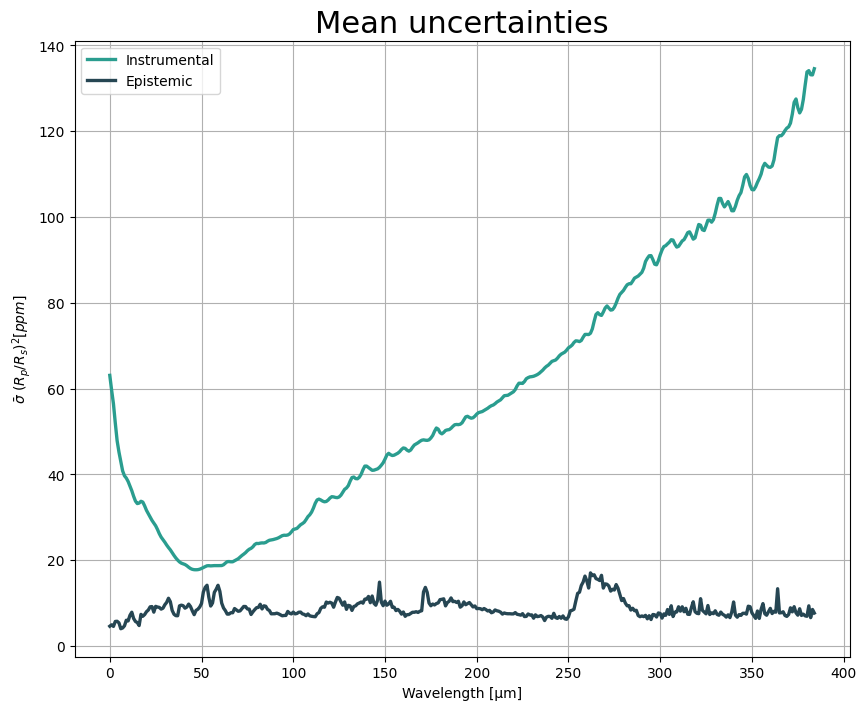

In [ ]:
wl_plot = wl[::-1]

plt.figure(figsize=(10, 8))
plt.plot(
    wl_plot,
    sigma_inst_d * 1e6,
    label="Instrumental",
    linewidth=2.4,
)
plt.plot(
    wl_plot,
    sigma_epi_med * 1e6,
    label="Epistemic (median across samples)",
    linewidth=2.4,
)

plt.xlabel("Wavelength [μm]")
plt.ylabel(r"$\bar{\sigma}$ $(R_p/R_s)^2$ [ppm]")
plt.title("Per-channel uncertainty summary", fontsize=22)
plt.legend()
plt.grid(True)
#plt.savefig("dae_uncertainties.png", dpi=300)
plt.show()

Indices seleccionados (Originales): [5, 331966, 13423]


C:\Users\User\AppData\Local\Temp\ipykernel_26228\1049567338.py:146: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)
C:\Users\User\AppData\Local\Temp\ipykernel_26228\1049567338.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


>>> Plot guardado: plots/exp0-final_style-RANDOM-IndependentAxes-total_uq-1Transit.png


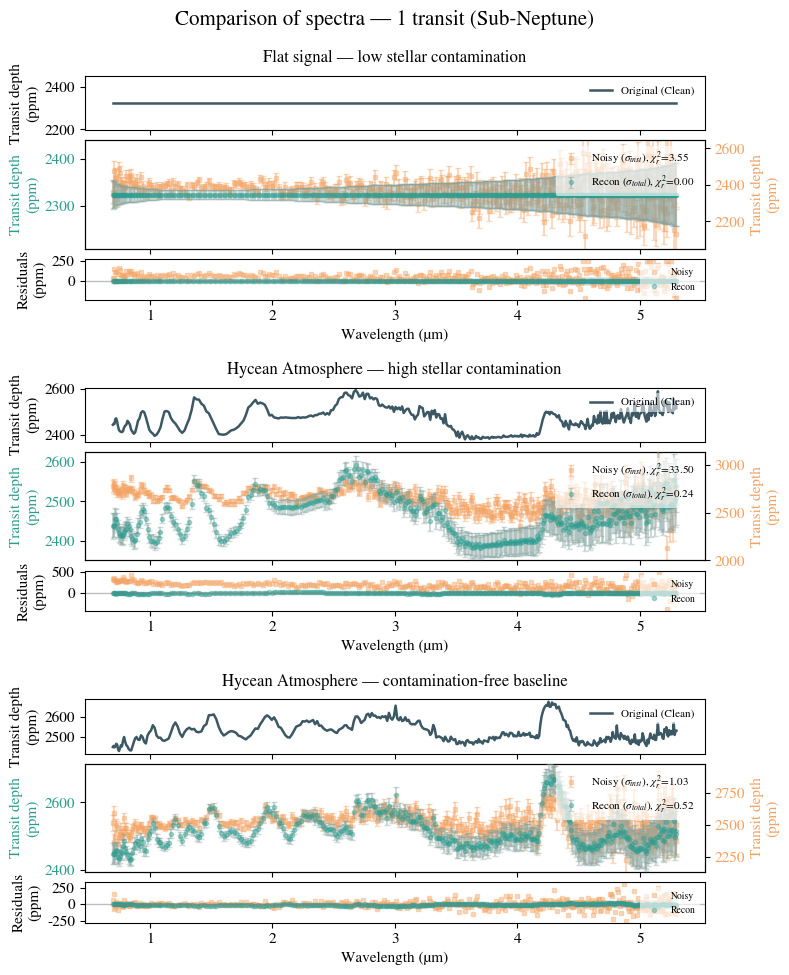

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter


def _resolve_plot_arrays() -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """
    Resolve plotting arrays from the current notebook environment.

    Expected to exist (defined earlier in the notebook):
      - recon_mean
      - sigma_total
      - X_clean_raw
      - X_noisy_raw
      - errors
      - waves
    """
    y_recon_all = np.asarray(recon_mean)
    sigma_total_all = np.asarray(sigma_total)
    y_clean_all = np.asarray(X_clean_raw.values)
    y_noisy_all = np.asarray(X_noisy_raw.values)
    sigma_inst = np.asarray(errors)
    waves_i = np.asarray(waves)[::-1]
    return y_recon_all, sigma_total_all, y_clean_all, y_noisy_all, sigma_inst, waves_i


def _compute_offsets() -> tuple[int, int, int]:
    """
    Compute indexing constants for the concatenated dataset layout.

    Expected to exist:
      - NREP_PLANET, NREP_FLAT, k2_18b_contam
    """
    n_rep_p = int(NREP_PLANET)
    n_rep_f = int(NREP_FLAT)
    len_k2_original = int(len(k2_18b_contam))
    offset_flats = len_k2_original * n_rep_p
    return n_rep_p, n_rep_f, offset_flats


def create_plot_with_your_style(uncertainty_type: str) -> None:
    """
    Plot three randomly selected regimes with a 3-panel layout per regime:
      1) Clean spectrum
      2) Noisy vs reconstructed (twin y-axes, independent scaling)
      3) Residuals with uncertainty band

    Notes:
      - Uses *independent* y-limits for noisy and recon axes (more readable).
      - Adds chi2_r annotations in legend entries.

    Parameters
    ----------
    uncertainty_type
        Either "instrumental" or "total".
    """
    if uncertainty_type not in {"instrumental", "total"}:
        raise ValueError("uncertainty_type must be 'instrumental' or 'total'.")

    (
        y_recon_all,
        sigma_total_all,
        y_clean_all,
        y_noisy_all,
        sigma_inst,
        waves_i,
    ) = _resolve_plot_arrays()

    n_rep_p, n_rep_f, offset_flats = _compute_offsets()

    cand_flat = flat_contam[
        (flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)
    ].index
    cand_high = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)
    ].index
    cand_none = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)
    ].index

    idx_flat = int(np.random.choice(cand_flat))
    idx_high = int(np.random.choice(cand_high))
    idx_none = int(np.random.choice(cand_none))

    idx_list_orig = [idx_flat, idx_high, idx_none]
    is_flat_mask = [True, False, False]

    print(f"Selected original indices: {idx_list_orig}")

    colors = {
        "original": "#264653",
        "reconstructed": "#2A9D8F",
        "noisy_points": "#F4A261",
        "fill_uq_resid": "#cccccc80",
    }

    titles = [
        "Flat signal — low stellar contamination",
        "Hycean atmosphere — high stellar contamination",
        "Hycean atmosphere — contamination-free baseline",
    ]

    plt.rcParams.update({"font.size": 11})

    n_groups = len(idx_list_orig)
    spacer = 2.5
    height_ratios: list[float] = []
    for i in range(n_groups):
        height_ratios.extend([2.0, 4.0, 1.5])
        if i < n_groups - 1:
            height_ratios.append(spacer)

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        # Map a base index to a "replicate-expanded" index.
        if is_flat:
            start_pos = offset_flats + (idx_orig * n_rep_f)
            final_idx = start_pos + int(np.random.randint(0, n_rep_f))
        else:
            start_pos = idx_orig * n_rep_p
            final_idx = start_pos + int(np.random.randint(0, n_rep_p))

        base = 4 * i
        ax_clean = fig.add_subplot(gs[base])
        ax_mix = fig.add_subplot(gs[base + 1], sharex=ax_clean)
        ax_resid = fig.add_subplot(gs[base + 2], sharex=ax_clean)

        ax_clean.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        y_clean = y_clean_all[final_idx]
        y_noisy = y_noisy_all[final_idx]
        y_recon = y_recon_all[final_idx]

        if uncertainty_type == "instrumental":
            sigma_recon = sigma_inst
            recon_sigma_label = r"\sigma_{inst}"
        else:
            sigma_recon = sigma_total_all[final_idx]
            recon_sigma_label = r"\sigma_{total}"

        chi2r_noisy = chi2_r(
            y_clean[None, :],
            y_noisy[None, :],
            sigma_inst,
            p=0,
        )[0]
        chi2r_recon = chi2_r(
            y_clean[None, :],
            y_recon[None, :],
            sigma_recon,
            p=0,
        )[0]

        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6

        sigma_inst_ppm = sigma_inst * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        # Panel 1: Clean spectrum
        ax_clean.plot(
            waves_i,
            y_clean_ppm,
            color=colors["original"],
            linewidth=1.8,
            alpha=0.9,
            label="Original (Clean)",
        )
        ax_clean.set_ylabel("Transit depth\n(ppm)")
        ax_clean.set_title(titles[i], fontsize=12)

        leg1 = ax_clean.legend(
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.55,
        )
        leg1.set_zorder(1000)

        # Panel 2: Noisy vs Recon (twin y-axis)
        ax_mix_r = ax_mix.twinx()

        ax_clean.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_r.patch.set_alpha(0.0)

        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors["reconstructed"])
        ax_mix.tick_params(axis="y", labelcolor=colors["reconstructed"])

        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors["noisy_points"])
        ax_mix_r.tick_params(axis="y", labelcolor=colors["noisy_points"])

        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_noisy:.2f}"
        ax_mix_r.errorbar(
            waves_i,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=colors["noisy_points"],
            fmt="s",
            capsize=2,
            alpha=0.4,
            markersize=3,
            zorder=8,
            label=noisy_label,
        )

        recon_label = rf"Recon ({recon_sigma_label}), $\chi^2_r$={chi2r_recon:.2f}"
        ax_mix.errorbar(
            waves_i,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=colors["reconstructed"],
            fmt="o",
            capsize=2,
            alpha=0.4,
            markersize=3,
            zorder=9,
            label=recon_label,
        )

        # Independent axis limits (each axis gets its own margins).
        y_min_rec, y_max_rec = float(np.min(y_recon_ppm)), float(np.max(y_recon_ppm))
        y_min_noi, y_max_noi = float(np.min(y_noisy_ppm)), float(np.max(y_noisy_ppm))

        margin_rec = (y_max_rec - y_min_rec) * 0.15
        margin_noi = (y_max_noi - y_min_noi) * 0.15

        ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)
        ax_mix_r.set_ylim(y_min_noi - margin_noi, y_max_noi + margin_noi)

        lines_left, labels_left = ax_mix.get_legend_handles_labels()
        lines_right, labels_right = ax_mix_r.get_legend_handles_labels()

        leg2 = ax_mix.legend(
            lines_right + lines_left,
            labels_right + labels_left,
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )
        leg2.set_zorder(1000)

        # Panel 3: Residuals + uncertainty band
        resid_noisy = (y_noisy - y_clean) * 1e6
        resid_recon = (y_recon - y_clean) * 1e6

        ax_resid.fill_between(
            waves_i,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=colors["fill_uq_resid"],
            zorder=0 if uncertainty_type == "total" else 5,
        )

        ax_resid.plot(
            waves_i,
            resid_noisy,
            "s",
            color=colors["noisy_points"],
            alpha=0.4,
            markersize=3,
            label="Noisy",
            zorder=1,
        )
        ax_resid.plot(
            waves_i,
            resid_recon,
            "o",
            color=colors["reconstructed"],
            alpha=0.4,
            markersize=3,
            label="Recon",
            zorder=2,
        )

        ax_resid.axhline(0.0, color="gray", linewidth=1.0, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (µm)", fontsize=11)
        ax_resid.legend(
            fontsize=7,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )

    transit_text = (
        f"{T_TRANSITS} transit(s)" if "T_TRANSITS" in globals() else "transits"
    )
    fig.suptitle(
        f"Comparison of spectra — {transit_text} (Sub-Neptune)",
        fontsize=15,
        y=0.94,
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    os.makedirs("plots", exist_ok=True)
    out_base = (
        f"plots/exp0-final_style-RANDOM-IndependentAxes-"
        f"{uncertainty_type}_uq"
    )
    #plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    #print(f">>> Saved plot: {out_base}.png")
    plt.show()


create_plot_with_your_style(uncertainty_type="total")


Indices seleccionados (Base): [5, 339747, 11020]


C:\Users\User\AppData\Local\Temp\ipykernel_26228\4208942961.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.0, 1, 0.93], h_pad=0.5)


>>> Plot guardado: plots/final_random_selection-total_uq.png


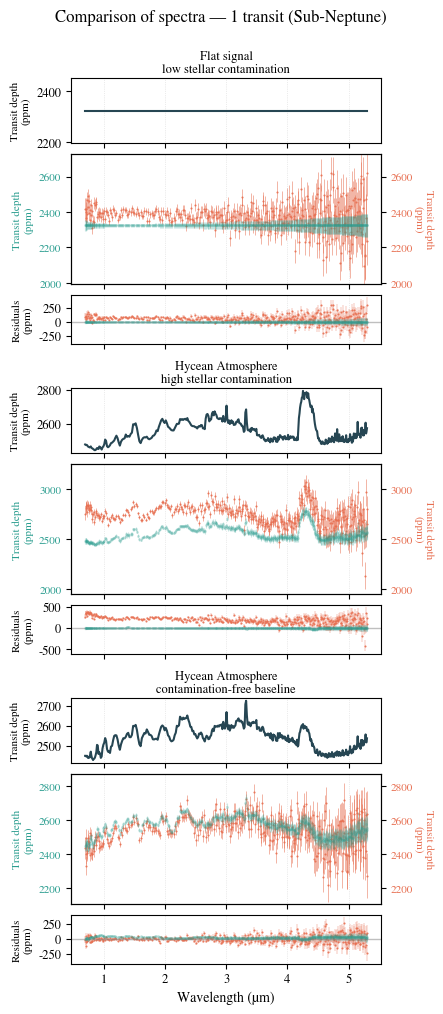

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter


def _resolve_plot_arrays() -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """
    Resolve plotting arrays from the current notebook environment.

    Expected to exist:
      - recon_mean, sigma_total, X_clean_raw, X_noisy_raw, errors, waves
    """
    y_recon_all = np.asarray(recon_mean)
    sigma_total_all = np.asarray(sigma_total)
    y_clean_all = np.asarray(X_clean_raw.values)
    y_noisy_all = np.asarray(X_noisy_raw.values)
    sigma_inst = np.asarray(errors)
    waves_i = np.asarray(waves)[::-1]
    return y_recon_all, sigma_total_all, y_clean_all, y_noisy_all, sigma_inst, waves_i


def _compute_offsets() -> tuple[int, int, int]:
    """
    Compute indexing constants for the concatenated dataset layout.

    Expected to exist:
      - NREP_PLANET, NREP_FLAT, k2_18b_contam
    """
    n_rep_p = int(NREP_PLANET)
    n_rep_f = int(NREP_FLAT)
    len_k2_original = int(len(k2_18b_contam))
    offset_flats = len_k2_original * n_rep_p
    return n_rep_p, n_rep_f, offset_flats


def create_plot_random_selection(uncertainty_type: str) -> None:
    """
    Compact 3×(clean/mix/residual) plot with serif styling.

    Key differences vs. Plot A:
      - More compact canvas and tighter typography.
      - Syncs y-limits between noisy/recon axes (single combined range).
      - Adds light x-grid guides for visual alignment.

    Parameters
    ----------
    uncertainty_type
        Either "instrumental" or "total".
    """
    if uncertainty_type not in {"instrumental", "total"}:
        raise ValueError("uncertainty_type must be 'instrumental' or 'total'.")

    (
        y_recon_all,
        sigma_total_all,
        y_clean_all,
        y_noisy_all,
        sigma_inst,
        waves_i,
    ) = _resolve_plot_arrays()

    n_rep_p, n_rep_f, offset_flats = _compute_offsets()

    cand_flat = flat_contam[
        (flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)
    ].index
    cand_high = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)
    ].index
    cand_none = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)
    ].index

    idx_flat = int(np.random.choice(cand_flat))
    idx_high = int(np.random.choice(cand_high))
    idx_none = int(np.random.choice(cand_none))

    idx_list_orig = [idx_flat, idx_high, idx_none]
    is_flat_mask = [True, False, False]

    print(f"Selected base indices: {idx_list_orig}")

    colors = {
        "original": "#264653",
        "reconstructed": "#2A9D8F",
        "noisy_points": "#E76F51",
        "fill_uq_resid": "#cccccc80",
    }

    titles = [
        "Flat signal\nlow stellar contamination",
        "Hycean Atmosphere\nhigh stellar contamination",
        "Hycean Atmosphere\ncontamination-free baseline",
    ]

    plt.rcParams.update({"font.size": 9, "font.family": "serif"})

    n_groups = len(idx_list_orig)
    spacer = 0.7
    height_ratios: list[float] = []
    for i in range(n_groups):
        height_ratios.extend([2.0, 4.0, 1.5])
        if i < n_groups - 1:
            height_ratios.append(spacer)

    fig = plt.figure(figsize=(4, 11.5))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    main_ax = None

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        if is_flat:
            start_pos = offset_flats + (idx_orig * n_rep_f)
            final_idx = start_pos + int(np.random.randint(0, n_rep_f))
        else:
            start_pos = idx_orig * n_rep_p
            final_idx = start_pos + int(np.random.randint(0, n_rep_p))

        base = 4 * i

        if main_ax is None:
            ax_clean = fig.add_subplot(gs[base])
            main_ax = ax_clean
        else:
            ax_clean = fig.add_subplot(gs[base], sharex=main_ax)

        ax_mix = fig.add_subplot(gs[base + 1], sharex=main_ax)
        ax_resid = fig.add_subplot(gs[base + 2], sharex=main_ax)

        # Light x-grid to help track wavelength alignment across panels.
        for ax in (ax_clean, ax_mix, ax_resid):
            ax.grid(
                axis="x",
                color="gray",
                linestyle=":",
                linewidth=0.5,
                alpha=0.3,
            )

        ax_clean.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        if i < n_groups - 1:
            ax_resid.tick_params(labelbottom=False)
        else:
            ax_resid.tick_params(labelbottom=True)
            ax_resid.set_xlabel("Wavelength (µm)", fontsize=10)

        y_clean = y_clean_all[final_idx]
        y_noisy = y_noisy_all[final_idx]
        y_recon = y_recon_all[final_idx]

        sigma_recon = sigma_inst if uncertainty_type == "instrumental" else sigma_total_all[
            final_idx
        ]

        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6

        sigma_inst_ppm = sigma_inst * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        # Panel 1: Clean
        ax_clean.plot(
            waves_i,
            y_clean_ppm,
            color=colors["original"],
            linewidth=1.5,
            alpha=1.0,
        )
        ax_clean.set_ylabel("Transit depth\n(ppm)", fontsize=8)
        ax_clean.set_title(titles[i], fontsize=9, pad=4)

        # Panel 2: Mix (twin axis)
        ax_mix_r = ax_mix.twinx()

        ax_clean.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_r.patch.set_alpha(0.0)

        ax_mix.set_ylabel(
            "Transit depth\n(ppm)",
            color=colors["reconstructed"],
            fontsize=8,
        )
        ax_mix.tick_params(
            axis="y",
            labelcolor=colors["reconstructed"],
            labelsize=8,
        )

        ax_mix_r.set_ylabel(
            "Transit depth\n(ppm)",
            color=colors["noisy_points"],
            fontsize=8,
            rotation=270,
            labelpad=15,
        )
        ax_mix_r.tick_params(
            axis="y",
            labelcolor=colors["noisy_points"],
            labelsize=8,
        )

        # Noisy (orange/red)
        ax_mix_r.errorbar(
            waves_i,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=colors["noisy_points"],
            fmt="o",
            alpha=0.9,
            markersize=1.5,
            markeredgewidth=0.0,
            elinewidth=0.4,
            capsize=0,
            zorder=1,
        )

        # Recon (green)
        ax_mix.errorbar(
            waves_i,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=colors["reconstructed"],
            fmt="o",
            alpha=0.25,
            markersize=2.0,
            markeredgewidth=0.0,
            elinewidth=0.8,
            capsize=0,
            zorder=10,
        )

        # Synced y-limits between both axes (single combined range).
        all_vals = np.concatenate([y_noisy_ppm, y_recon_ppm])
        y_min, y_max = float(np.min(all_vals)), float(np.max(all_vals))
        margin = (y_max - y_min) * 0.20
        ax_mix.set_ylim(y_min - margin, y_max + margin)
        ax_mix_r.set_ylim(y_min - margin, y_max + margin)

        # Panel 3: Residuals
        resid_noisy = (y_noisy - y_clean) * 1e6
        resid_recon = (y_recon - y_clean) * 1e6

        fill_z = 5 if uncertainty_type == "instrumental" else 0
        ax_resid.fill_between(
            waves_i,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=colors["fill_uq_resid"],
            zorder=fill_z,
            alpha=0.25,
        )

        ax_resid.errorbar(
            waves_i,
            resid_noisy,
            yerr=sigma_inst_ppm,
            fmt="o",
            color=colors["noisy_points"],
            alpha=0.9,
            markersize=1.5,
            markeredgewidth=0.0,
            elinewidth=0.3,
            zorder=1,
        )

        ax_resid.errorbar(
            waves_i,
            resid_recon,
            yerr=sigma_recon_ppm,
            fmt="o",
            color=colors["reconstructed"],
            alpha=0.25,
            markersize=2.0,
            markeredgewidth=0.0,
            elinewidth=0.6,
            zorder=2,
        )

        ax_resid.axhline(0.0, color="gray", linewidth=1.0, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)", fontsize=8)

    transit_text = f"{N_TRANSITS} transits" if "N_TRANSITS" in globals() else "transits"
    fig.suptitle(
        f"Comparison of spectra — {transit_text} (Sub-Neptune)",
        fontsize=12,
        y=0.94,
    )

    plt.tight_layout(rect=[0, 0.0, 1, 0.93], h_pad=0.5)

    os.makedirs("plots", exist_ok=True)
    out_base = f"plots/final_random_selection-{uncertainty_type}_uq"
    #plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    #print(f">>> Saved plot: {out_base}.png")
    plt.show()


create_plot_random_selection(uncertainty_type="total")


# Experiment B — Multi-transit sensitivity 

In [ ]:
k2_18b_mult = mult_df(k2_18b, n_points=385, n_mult=0)
flat_mult = mult_df(flat, n_points=385, n_mult=0)

print(k2_18b_mult.shape)
print(k2_18b_mult.params.columns[:10])
print(k2_18b_mult.data.shape)


In [ ]:
N_TRANSITS_LIST = [1, 2, 5, 10]

NREP_PLANET = 3
NREP_FLAT = 300
T_PASSES_DROPOUT = 50
EPS_SIGMA = 1e-12

WL_GRID_SIM = np.linspace(0.6, 5.3, 1000)


def filter_by_stellar_params(
    df: pd.DataFrame,
    f_spot_val: float,
    f_fac_val: float,
) -> pd.DataFrame:
    mask = (df["f_spot"] == f_spot_val) & (df["f_fac"] == f_fac_val)
    return df.loc[mask]


unique_f_spot = np.sort(flat_contam["f_spot"].unique())
unique_f_fac = np.sort(flat_contam["f_fac"].unique())

print(f">>> Unique f_spot: {unique_f_spot}")
print(f">>> Unique f_fac:  {unique_f_fac}")

print("Building master CLEAN dataset (one-time)...")
df_clean_master = pd.concat(
    [
        generate_df_with_noise_std(k2_18b_mult, NREP_PLANET, 0.0),
        generate_df_with_noise_std(flat_mult, NREP_FLAT, 0.0),
    ],
    ignore_index=True,
)
print(f"Master CLEAN dataset ready. Shape: {df_clean_master.shape}")

all_results: dict[tuple[float, float], dict[str, list]] = {}
print("\nStarting sensitivity & UQ analysis...")

for f_spot_val in unique_f_spot:
    for f_fac_val in unique_f_fac:
        df_clean_filtered = df_clean_master

        if df_clean_filtered.empty:
            continue

        x_clean_raw = df_clean_filtered.iloc[:, -n_points:]

        scores: dict[str, list] = {
            "n_transits": [],
            "chi2r_noisy_clean_inst": [],
            "chi2r_recon_clean_inst": [],
            "chi2r_recon_clean_total": [],
            "sigma_inst_mean_lambda": [],
            "sigma_ale_mean_lambda": [],
            "sigma_epi_mean_lambda": [],
            "sigma_total_mean_lambda": [],
        }

        desc = f"Processing f_spot={f_spot_val}, f_fac={f_fac_val}"

        for nt in tqdm(N_TRANSITS_LIST, desc=desc, leave=False):
            _, instrumental_noise = get_k218_prism_noise_flat(
                wl_grid_um=WL_GRID_SIM,
                n_transits=nt,
                T_s=3500.0,
                plot=False,
                cut_first=18,
            )

            instrumental_noise = instrumental_noise[::-1]
            if instrumental_noise.shape[0] != n_points:
                instrumental_noise = instrumental_noise[:n_points]

            df_noisy = pd.concat(
                [
                    generate_df_with_noise_std(
                        k2_18b_contam, NREP_PLANET, instrumental_noise
                    ),
                    generate_df_with_noise_std(
                        flat_contam, NREP_FLAT, instrumental_noise
                    ),
                ],
                ignore_index=True,
            )

            df_noisy_filtered = filter_by_stellar_params(
                df_noisy, f_spot_val, f_fac_val
            )
            if df_noisy_filtered.empty:
                continue

            x_noisy_raw = df_noisy_filtered.iloc[:, -n_points:]

            sigma_ale = calc_aleatoric_half_instrumental(
                sigma_inst=instrumental_noise,
                shape=x_noisy_raw.shape,
            )

            mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
                autoencoder=autoencoder,
                x_noisy_raw=x_noisy_raw,
                x_clean_raw=x_clean_raw,
                t_passes=T_PASSES_DROPOUT,
            )

            sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)
            recon_mean = mean_dropout

            sigma_inst_mean_lambda = instrumental_noise.astype(np.float32)
            sigma_ale_mean_lambda = np.nanmean(sigma_ale, axis=0).astype(np.float32)
            sigma_epi_mean_lambda = np.nanmean(sigma_epi, axis=0).astype(np.float32)
            sigma_total_mean_lambda = np.nanmean(sigma_total, axis=0).astype(np.float32)

            chi2r_1 = chi2_r(
                x_clean_raw.values,
                x_noisy_raw.values,
                instrumental_noise,
                p=0,
            )
            chi2r_2 = chi2_r(
                x_clean_raw.values,
                recon_mean,
                instrumental_noise,
                p=0,
            )
            chi2r_3 = chi2_r(
                x_clean_raw.values,
                recon_mean,
                sigma_total,
                p=0,
            )

            scores["n_transits"].append(nt)
            scores["chi2r_noisy_clean_inst"].append(float(np.mean(chi2r_1)))
            scores["chi2r_recon_clean_inst"].append(float(np.mean(chi2r_2)))
            scores["chi2r_recon_clean_total"].append(float(np.mean(chi2r_3)))
            scores["sigma_inst_mean_lambda"].append(sigma_inst_mean_lambda)
            scores["sigma_ale_mean_lambda"].append(sigma_ale_mean_lambda)
            scores["sigma_epi_mean_lambda"].append(sigma_epi_mean_lambda)
            scores["sigma_total_mean_lambda"].append(sigma_total_mean_lambda)

            del df_noisy, df_noisy_filtered, x_noisy_raw, recon_mean, sigma_total

        all_results[(float(f_spot_val), float(f_fac_val))] = scores
        gc.collect()

print("\nDone!")

output_filename = "results_sensitivity_uq_final.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(all_results, f)

print(f">>> Results saved to: '{output_filename}'")


<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_76392\2932864813.py:81: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')


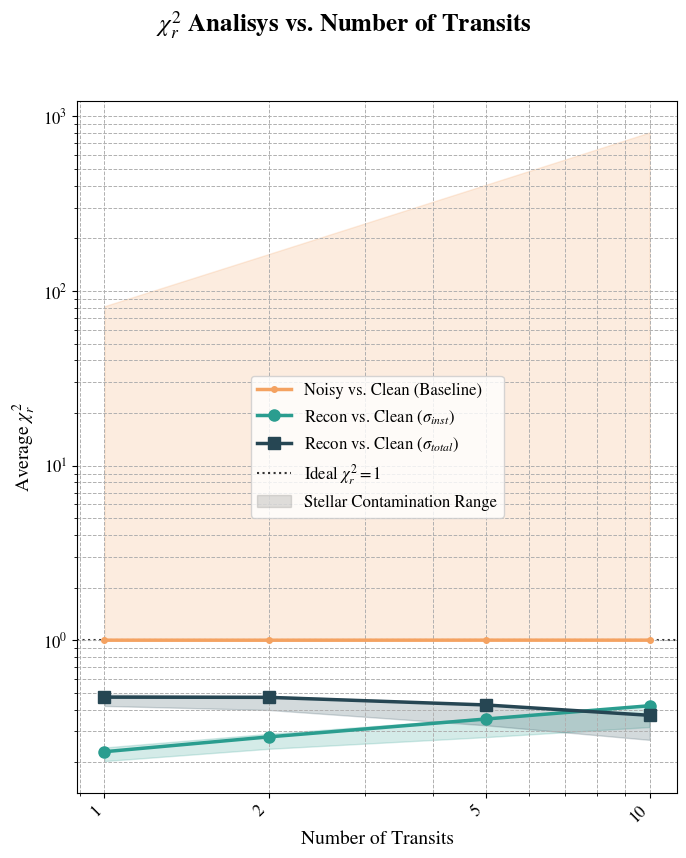

In [ ]:
def load_results(path: str) -> dict[tuple[float, float], dict[str, list]]:
    with open(path, "rb") as f:
        return pickle.load(f)


def get_min_max_across_cases(
    metric: str,
    transit_list: list[int],
    results: dict[tuple[float, float], dict[str, list]],
) -> tuple[np.ndarray, np.ndarray]:
    mins: list[float] = []
    maxs: list[float] = []

    for nt in transit_list:
        vals: list[float] = []
        for data in results.values():
            if nt not in data["n_transits"]:
                continue
            idx = data["n_transits"].index(nt)
            v = data[metric][idx]
            if np.isfinite(v):
                vals.append(float(v))

        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)

    return np.asarray(mins, dtype=float), np.asarray(maxs, dtype=float)


filename = "results_sensitivity_uq_final.pkl"
results = load_results(filename)

base_key = (0.0, 0.0)
case_base = results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case for (f_spot=0, f_fac=0).")

transits_plot = case_base["n_transits"]
x_vals = np.asarray(transits_plot, dtype=float)

metrics = [
    "chi2r_noisy_clean_inst",
    "chi2r_recon_clean_inst",
    "chi2r_recon_clean_total",
]

legend_labels = {
    "chi2r_noisy_clean_inst": r"Noisy vs. Clean (Baseline)",
    "chi2r_recon_clean_inst": r"Recon vs. Clean ($\sigma_{inst}$)",
    "chi2r_recon_clean_total": r"Recon vs. Clean ($\sigma_{total}$)",
}

palette = {
    "chi2r_noisy_clean_inst": "#F4A261",
    "chi2r_recon_clean_inst": "#2A9D8F",
    "chi2r_recon_clean_total": "#264653",
}

markers = {
    "chi2r_noisy_clean_inst": ".",
    "chi2r_recon_clean_inst": "o",
    "chi2r_recon_clean_total": "s",
}

fig, ax = plt.subplots(figsize=(7, 9))
fig.suptitle(
    r"$\chi^2_r$ Analysis vs. Number of Transits",
    fontsize=18,
    y=0.98,
    weight="bold",
)

for metric in metrics:
    color = palette[metric]
    mn, mx = get_min_max_across_cases(metric, transits_plot, results)
    ax.fill_between(x_vals, mn, mx, color=color, alpha=0.20)

    y_base = [
        case_base[metric][case_base["n_transits"].index(nt)]
        if nt in case_base["n_transits"]
        else np.nan
        for nt in transits_plot
    ]
    ax.plot(
        x_vals,
        y_base,
        marker=markers[metric],
        markersize=8,
        color=color,
        linewidth=2.5,
        label=legend_labels[metric],
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"Average $\chi^2_r$", fontsize=14)
ax.set_xlabel("Number of Transits", fontsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.7)
ax.tick_params(axis="both", which="major", labelsize=12)

ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    zorder=0,
    label=r"Ideal $\chi^2_r = 1$",
)

handles, labels = ax.get_legend_handles_labels()
handles.append(plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.25))
labels.append("Stellar Contamination Range")
ax.legend(handles=handles, labels=labels, fontsize=12, loc="best")

ax.set_xticks(transits_plot)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(os.path.join(output_dir, "chi2r_analysis_all.png"), dpi=300)
#plt.savefig(os.path.join(output_dir, "chi2r_analysis_all.svg"))
plt.show()


<>:78: SyntaxWarning: invalid escape sequence '\c'
<>:78: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_38860\1342259057.py:78: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analysis: Impact of Stellar Activity', fontsize=18, y=0.96, weight='bold')
C:\Users\User\AppData\Local\Temp\ipykernel_38860\1342259057.py:177: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 4
  ax.legend(handles=handles, labels=labels_ax, fontsize=9, loc='upper left', framealpha=0.7)


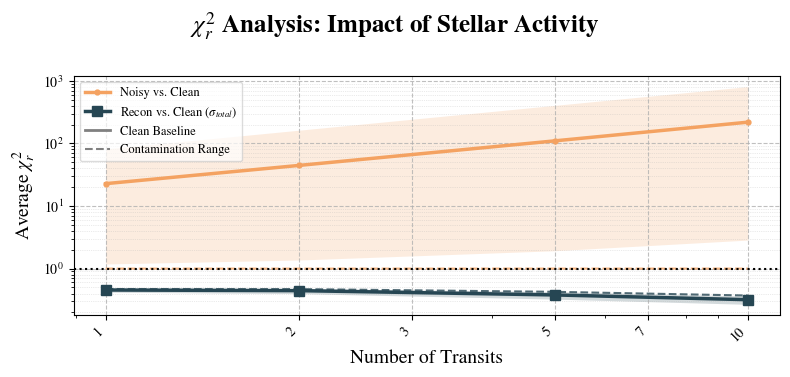

In [ ]:
def load_results(path: str) -> dict[tuple[float, float], dict[str, list]]:
    with open(path, "rb") as f:
        return pickle.load(f)


def contaminated_stats(
    metric: str,
    transits: list[int],
    results: dict[tuple[float, float], dict[str, list]],
    base_key: tuple[float, float],
) -> tuple[list[float], list[float], list[float]]:
    mins: list[float] = []
    maxs: list[float] = []
    means: list[float] = []

    for nt in transits:
        vals: list[float] = []
        for key, data in results.items():
            if key == base_key:
                continue
            if nt not in data["n_transits"]:
                continue
            idx = data["n_transits"].index(nt)
            v = data[metric][idx]
            if np.isfinite(v):
                vals.append(float(v))

        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
            means.append(float(np.mean(vals)))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)
            means.append(np.nan)

    return mins, maxs, means


filename = "results_sensitivity_uq_final.pkl"
results = load_results(filename)

base_key = (0.0, 0.0)
case_base = results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case for (f_spot=0, f_fac=0).")

transits_plot = case_base["n_transits"]

metrics = [
    "chi2r_noisy_clean_inst",
    "chi2r_recon_clean_total",
]

metric_labels = {
    "chi2r_noisy_clean_inst": r"Noisy vs. Clean",
    "chi2r_recon_clean_total": r"Recon vs. Clean ($\sigma_{total}$)",
}

palette = {
    "chi2r_noisy_clean_inst": "#F4A261",
    "chi2r_recon_clean_total": "#264653",
}

markers = {
    "chi2r_noisy_clean_inst": ".",
    "chi2r_recon_clean_total": "s",
}

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(
    r"$\chi^2_r$ Analysis: Impact of Stellar Activity",
    fontsize=18,
    y=0.96,
    weight="bold",
)

for metric in metrics:
    color = palette[metric]
    marker = markers[metric]

    mins, maxs, means = contaminated_stats(metric, transits_plot, results, base_key)

    ax.fill_between(
        transits_plot,
        mins,
        maxs,
        color=color,
        alpha=0.2,
        linewidth=0.0,
    )

    ax.plot(
        transits_plot,
        means,
        marker=marker,
        markersize=7,
        color=color,
        linewidth=2.5,
        linestyle="-",
        label=metric_labels[metric],
    )

    y_base = [
        case_base[metric][case_base["n_transits"].index(nt)]
        if nt in case_base["n_transits"]
        else np.nan
        for nt in transits_plot
    ]
    ax.plot(
        transits_plot,
        y_base,
        color=color,
        linewidth=1.5,
        linestyle="--",
        alpha=0.8,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"Average $\chi^2_r$", fontsize=14)
ax.set_xlabel("Number of Transits", fontsize=14)

custom_ticks = sorted(set(transits_plot) | {3, 7})
ax.set_xticks(custom_ticks)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

locmin = mticker.LogLocator(
    base=10.0,
    subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
    numticks=12,
)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.8)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.5)

ax.axhline(1.0, color="black", linestyle=":", linewidth=1.5)

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="gray", linestyle="--", linewidth=1.5))
labels.append("Clean Baseline")
handles.append(plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.2))
labels.append("Contamination Range")
ax.legend(handles=handles, labels=labels, fontsize=9, loc="upper left", framealpha=0.7)

output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(
#    os.path.join(output_dir, "exp3-chi2r_analysis_final_02-comp.png"),
#    dpi=500,
#)
plt.show()


# Experiment C - N+1 Molecule (DMS)

This section is intentionally simpler than the previous draft.

We only do two things:

1. generate the synthetic transit spectra for a Hycean-like atmosphere with **DMS**,
2. evaluate those spectra with the same contamination and noise procedures already used elsewhere in the notebook.

Only one artifact is saved in `specs/`:

- `specs/nplus1_dms_spectra.joblib`

## Step 1 - Generate and save the DMS spectra

The reference chemistry stays fixed at:

- `CO2 = -2`
- `CH4 = -1`
- `H2O = -3`
- `NH3 = -5`

and the new molecule is exactly `DMS`, with a grid from `-10` to `-1` in `log10(mixing ratio)`.

This section always regenerates the DMS grid from the physical model and then overwrites the saved file in `specs/`.


In [27]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm, TwoSlopeNorm

NPLUS1_OOD_GAS = "DMS"
NPLUS1_DMS_PARAMETER_SPACE = {"min": -10.0, "max": -2.0, "n": 9}
NPLUS1_DMS_GRID = np.linspace(
    NPLUS1_DMS_PARAMETER_SPACE["min"],
    NPLUS1_DMS_PARAMETER_SPACE["max"],
    NPLUS1_DMS_PARAMETER_SPACE["n"],
)
NPLUS1_FIXED_GASES = {
    "CO2": -2.0,
    "CH4": -1.0,
    "H2O": -3.0,
    "NH3": -5.0,
}
NPLUS1_TRANSITS_LIST = [1, 2, 5]
NPLUS1_NOISE_REPEATS = 100
NPLUS1_SPECTRA_PATH = Path("specs/nplus1_dms_spectra.joblib")

spectral_columns = list(k2_18b.columns[-n_points:])
base_param_columns = list(k2_18b.columns[:-n_points])
param_columns_nplus1 = base_param_columns.copy()
if "atm DMS" not in param_columns_nplus1:
    insert_at = param_columns_nplus1.index("atm NH3") + 1
    param_columns_nplus1.insert(insert_at, "atm DMS")


In [28]:
import multirex as mrex

# Build the same Hycean-like system used in the synthetic-spectrum notebook.
star = mrex.Star(
    temperature=3500,
    radius=0.468,
    mass=0.495,
    phoenix_path="",
)
planet = mrex.Planet(
    radius=2.461,
    mass=7.2,
)
atmosphere = mrex.Atmosphere(
    temperature=250,
    base_pressure=10e5,
    top_pressure=1e-3,
    fill_gas=["H2", "He"],
    cia=["H2-H2", "H2-He"],
)
planet.set_atmosphere(atmosphere)

system_dms = mrex.System(
    planet=planet,
    star=star,
    sma=0.1429,
)

# Reuse the same CIA setup as before.
mrex.Util.get_CIAs(["H2-H2", "H2-He"], path="CIA")

# Here the grid is only one-dimensional in the new molecule.
parameter_space_dms = {
    "planet.atmosphere.temperature": [250.0],
    "planet.atmosphere.composition.CO2": [NPLUS1_FIXED_GASES["CO2"]],
    "planet.atmosphere.composition.CH4": [NPLUS1_FIXED_GASES["CH4"]],
    "planet.atmosphere.composition.H2O": [NPLUS1_FIXED_GASES["H2O"]],
    "planet.atmosphere.composition.NH3": [NPLUS1_FIXED_GASES["NH3"]],
    "planet.atmosphere.composition.DMS": dict(NPLUS1_DMS_PARAMETER_SPACE),
}
print("Parameter space used for DMS:")
print(parameter_space_dms)

dms_clean_df = system_dms.explore_parameter_space(
    wn_grid=wn_grid,
    parameter_space=parameter_space_dms,
    header=True,
    observations=False,
    n_jobs=-1,
)
dms_clean_df = dms_clean_df.copy()

if "atm DMS" not in dms_clean_df.columns:
    raise KeyError("The generated dataframe does not contain the column 'atm DMS'.")

dms_clean_df = dms_clean_df[param_columns_nplus1 + spectral_columns].copy()
dms_clean_df.data = dms_clean_df.iloc[:, -n_points:]
dms_clean_df.params = dms_clean_df.iloc[:, :-n_points]

joblib.dump(pd.DataFrame(dms_clean_df), NPLUS1_SPECTRA_PATH)
print(f"Saved DMS spectra: {NPLUS1_SPECTRA_PATH}")
print(dms_clean_df[["atm CO2", "atm CH4", "atm H2O", "atm NH3", "atm DMS"]])


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\taurex\data\stellar\phoenix.py:198: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self._files[int(idx)]
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\taurex\data\profiles\pressure\pressureprofile.py:137: DeprecationWarning: SimplePressureProfile is deprecated. Use LogPressureProfile instead
  warn(
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\taurex\model\transmission.py:80: DeprecationWarning: SimpleForwardModel is deprecated. Use OneDForwardModel instead
  super().__init__(


The directory to Phoenix already exists in the specified path:  current directory
Parameter space used for DMS:
{'planet.atmosphere.temperature': [250.0], 'planet.atmosphere.composition.CO2': [-2.0], 'planet.atmosphere.composition.CH4': [-1.0], 'planet.atmosphere.composition.H2O': [-3.0], 'planet.atmosphere.composition.NH3': [-5.0], 'planet.atmosphere.composition.DMS': {'min': -10.0, 'max': -2.0, 'n': 9}}


100%|██████████| 9/9 [00:00<00:00, 9004.95it/s]


Saved DMS spectra: specs\nplus1_dms_spectra.joblib
   atm CO2  atm CH4  atm H2O  atm NH3  atm DMS
0     -2.0     -1.0     -3.0     -5.0    -10.0
1     -2.0     -1.0     -3.0     -5.0     -9.0
2     -2.0     -1.0     -3.0     -5.0     -8.0
3     -2.0     -1.0     -3.0     -5.0     -7.0
4     -2.0     -1.0     -3.0     -5.0     -6.0
5     -2.0     -1.0     -3.0     -5.0     -5.0
6     -2.0     -1.0     -3.0     -5.0     -4.0
7     -2.0     -1.0     -3.0     -5.0     -3.0
8     -2.0     -1.0     -3.0     -5.0     -2.0


C:\Users\User\AppData\Local\Temp\ipykernel_43332\195224948.py:57: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dms_clean_df.data = dms_clean_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\195224948.py:58: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dms_clean_df.params = dms_clean_df.iloc[:, :-n_points]


### Quick sanity check

Before applying contamination or noise, we inspect a few spectra from the DMS grid.

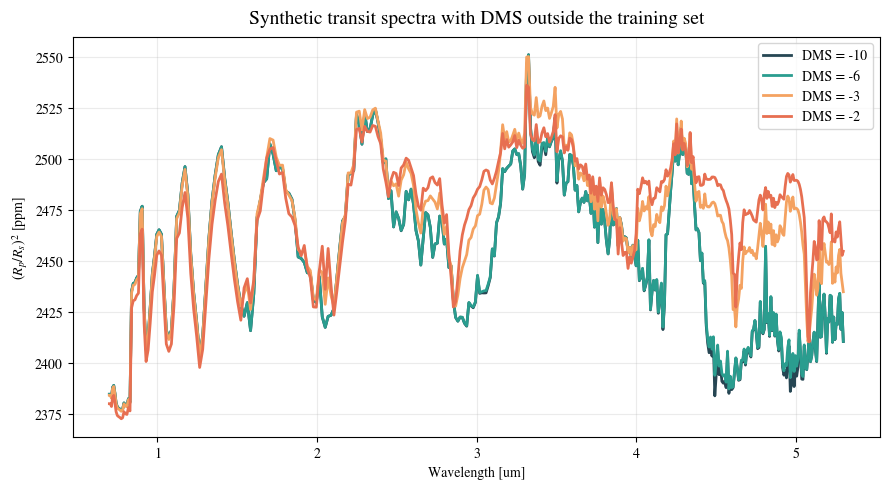

In [29]:
plt.figure(figsize=(9, 5))
for dms_value, color in zip([-10.0, -6.0, -3.0, -2.0], ["#264653", "#2A9D8F", "#F4A261", "#E76F51"]):
    dms_mask = np.isclose(
        pd.to_numeric(dms_clean_df["atm DMS"], errors="coerce").to_numpy(dtype=float),
        dms_value,
    )
    row = dms_clean_df.loc[dms_mask].iloc[0]
    plt.plot(
        np.asarray(waves, dtype=float),
        row[spectral_columns].to_numpy(dtype=float)[::-1] * 1e6,
        color=color,
        linewidth=2.0,
        label=f"DMS = {dms_value:.0f}",
    )

plt.xlabel("Wavelength [um]")
plt.ylabel(r"$(R_p/R_s)^2$ [ppm]")
plt.title("Synthetic transit spectra with DMS outside the training set")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## Step 2 - Apply the existing contamination and noise workflow

In this stage we do **not** define a new contamination method.
We reuse the notebook tools that already existed:

- `apply_contaminations_from_files(...)`
- `generate_df_with_noise_std(...)`
- `get_k218_prism_noise_flat(...)`
- `chi2_reduced(...)`

The clean reference remains the **uncontaminated** DMS grid.
Only the observed spectra receive stellar contamination and instrumental noise.


In [30]:
# Use the same stellar-contamination procedure already defined earlier.
dms_contam = apply_contaminations_from_files(
    contamination_files=contamination_files,
    df=dms_clean_df,
    n_points=n_points,
)

dms_clean_mult = mult_df(
    dms_clean_df,
    n_points=n_points,
    n_mult=len(contamination_files) - 1,
)

print("Contaminated DMS dataframe:", dms_contam.shape)
print("Clean replicated DMS dataframe:", dms_clean_mult.shape)
print(dms_contam[["f_spot", "f_fac", "atm DMS"]].head())

# Build one instrumental-noise vector per transit count.
sigma_by_transit = {}
wl_grid_sim = np.linspace(0.6, 5.3, 1000)
for nt in NPLUS1_TRANSITS_LIST:
    waves_pdx, sigma_raw = get_k218_prism_noise_flat(
        wl_grid_um=wl_grid_sim,
        n_transits=int(nt),
        t_star=TSTAR_K218,
        plot=False,
        cut_first=18,
    )
    sigma_by_transit[int(nt)] = resample_sigma_to_target_grid(
        waves_src=waves_pdx[::-1],
        sigma_src=sigma_raw[::-1],
        waves_tgt=waves,
    ).astype(np.float32)

print("Transit counts with cached sigma_inst:", list(sigma_by_transit))

C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_43332\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

Contaminated DMS dataframe: (144, 410)
Clean replicated DMS dataframe: (144, 410)
   f_spot  f_fac  atm DMS
0     0.0    0.0    -10.0
1     0.0    0.0     -9.0
2     0.0    0.0     -8.0
3     0.0    0.0     -7.0
4     0.0    0.0     -6.0
Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()


Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pandexo\engine\justdoit.py:382: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\gdaespec\\Sub_Neptune_Atmosphere\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Transit counts with cached sigma_inst: [1, 2, 5]


In [31]:
T_PASSES_DROPOUT = 50
EPS_SIGMA = 1e-12
results_frames = []

for nt in tqdm(NPLUS1_TRANSITS_LIST, desc="Transit counts"):
    sigma_inst = sigma_by_transit[int(nt)]

    # Follow the same Experiment A workflow: build the full noisy block and the
    # aligned clean block, then run the UQ stack once over the whole dataset.
    df_noisy = generate_df_with_noise_std(
        dms_contam,
        NPLUS1_NOISE_REPEATS,
        sigma_inst,
    )
    df_clean = generate_df_with_noise_std(
        dms_clean_mult,
        NPLUS1_NOISE_REPEATS,
        0.0,
    )

    X_noisy_raw = df_noisy.iloc[:, -n_points:]
    X_clean_raw = df_clean.iloc[:, -n_points:]

    sigma_ale = calc_aleatoric_half_instrumental(sigma_inst, X_noisy_raw.shape)
    recon_mean, sigma_epi = mc_dropout_sigma_anchor_clean(
        autoencoder_model=autoencoder,
        x_noisy_raw=X_noisy_raw,
        x_clean_raw=X_clean_raw,
        t_passes=T_PASSES_DROPOUT,
        batch_size=512,
    )
    sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)

    chi2r_noisy_vs_true = chi2_reduced(X_clean_raw.values, X_noisy_raw.values, sigma_inst, p=0)
    chi2r_recon_vs_true_inst = chi2_reduced(X_clean_raw.values, recon_mean, sigma_inst, p=0)
    chi2r_recon_vs_true_total = chi2_reduced(
        X_clean_raw.values,
        recon_mean,
        np.clip(sigma_total, EPS_SIGMA, np.inf),
        p=0,
    )

    frame = df_noisy.iloc[:, :-n_points].copy()
    frame = frame[["f_spot", "f_fac", "atm DMS"]].copy()
    frame[["f_spot", "f_fac", "atm DMS"]] = frame[["f_spot", "f_fac", "atm DMS"]].apply(
        pd.to_numeric,
        errors="coerce",
    )
    frame["n_transits"] = int(nt)
    frame["chi2r_noisy_vs_true"] = chi2r_noisy_vs_true
    frame["chi2r_recon_vs_true_inst"] = chi2r_recon_vs_true_inst
    frame["chi2r_recon_vs_true_total"] = chi2r_recon_vs_true_total
    frame["sigma_epi_mean"] = np.nanmean(sigma_epi, axis=1).astype(np.float32)

    results_frames.append(
        frame.groupby(["f_spot", "f_fac", "n_transits", "atm DMS"], as_index=False).mean(numeric_only=True)
    )

    del df_noisy, df_clean, X_noisy_raw, X_clean_raw
    del sigma_ale, recon_mean, sigma_epi, sigma_total
    gc.collect()

nplus1_results_df = pd.concat(results_frames, ignore_index=True)
nplus1_results_df = nplus1_results_df.sort_values(
    ["f_spot", "f_fac", "atm DMS", "n_transits"],
    ignore_index=True,
)

# Convert the grouped table back to numeric types before building masks in later plots.
result_numeric_cols = [
    "f_spot",
    "f_fac",
    "atm DMS",
    "n_transits",
    "chi2r_noisy_vs_true",
    "chi2r_recon_vs_true_inst",
    "chi2r_recon_vs_true_total",
    "sigma_epi_mean",
]
for col in result_numeric_cols:
    nplus1_results_df[col] = pd.to_numeric(nplus1_results_df[col], errors="coerce")

nplus1_results_df["n_transits"] = nplus1_results_df["n_transits"].astype(int)

# Keep the UQ-aware metric as the default one for the heatmaps.
nplus1_results_df["chi2r_recon_vs_true"] = nplus1_results_df["chi2r_recon_vs_true_total"]

# Compare improvement against the noisy baseline using the same sigma_inst in both terms.
nplus1_results_df["chi2r_excess_recon"] = (
    nplus1_results_df["chi2r_recon_vs_true_inst"] - nplus1_results_df["chi2r_noisy_vs_true"]
)

# Comparison against the ideal reduced chi-square value of 1.
nplus1_results_df["log10_chi2r_recon_vs_true"] = np.log10(
    np.clip(nplus1_results_df["chi2r_recon_vs_true"].to_numpy(dtype=float), EPS_SIGMA, np.inf)
)
nplus1_results_df["abs_log10_distance_to_ideal"] = np.abs(
    nplus1_results_df["log10_chi2r_recon_vs_true"]
)
nplus1_results_df["chi2r_recon_minus_ideal"] = (
    nplus1_results_df["chi2r_recon_vs_true"] - 1.0
)

print(nplus1_results_df.head())


Transit counts:   0%|          | 0/3 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:74: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:74: UserWarning: Pandas doesn't allow columns to 

MC Dropout: N=14400, D=385, batches=29, batch_size=512
  batch 1/29 done
  batch 11/29 done
  batch 21/29 done


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(64, 385))
  warnings.warn(msg)
Transit counts:  33%|███▎      | 1/3 [01:20<02:40, 80.07s/it]C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:74: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:73: UserWarning: Pandas doesn't allow columns to be 

MC Dropout: N=14400, D=385, batches=29, batch_size=512
  batch 1/29 done
  batch 11/29 done
  batch 21/29 done


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(64, 385))
  warnings.warn(msg)
Transit counts:  67%|██████▋   | 2/3 [02:39<01:19, 79.81s/it]C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:74: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\795280907.py:73: UserWarning: Pandas doesn't allow columns to be 

MC Dropout: N=14400, D=385, batches=29, batch_size=512
  batch 1/29 done
  batch 11/29 done
  batch 21/29 done


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(64, 385))
  warnings.warn(msg)
Transit counts: 100%|██████████| 3/3 [03:59<00:00, 79.74s/it]

   f_spot  f_fac  n_transits  atm DMS  chi2r_noisy_vs_true  \
0     0.0    0.0           1    -10.0             0.996064   
1     0.0    0.0           2    -10.0             1.016412   
2     0.0    0.0           5    -10.0             0.998924   
3     0.0    0.0           1     -9.0             1.016507   
4     0.0    0.0           2     -9.0             0.997018   

   chi2r_recon_vs_true_inst  chi2r_recon_vs_true_total  sigma_epi_mean  \
0                  0.027936                   0.089811        0.000005   
1                  0.042268                   0.126561        0.000004   
2                  0.093653                   0.250030        0.000004   
3                  0.031022                   0.098151        0.000005   
4                  0.045532                   0.135605        0.000004   

   chi2r_recon_vs_true  chi2r_excess_recon  log10_chi2r_recon_vs_true  \
0             0.089811           -0.968129                  -1.046669   
1             0.126561           -0.

## Step 3 - Read the maps in terms of the ideal value $\chi^2_r = 1$

The maps below answer four complementary questions.

### Plot 1 - Mean `log10(chi2_r)` across all stellar-contamination cases

This is the fastest global summary.

- **x-axis**: number of transits
- **y-axis**: `log10(DMS)`
- **color**: `log10(chi2_r)` for the reconstruction relative to the true DMS spectrum

For these maps, the reconstruction is evaluated with the **same UQ route as the main notebook**:
MC Dropout + clean-anchor de-normalization + `sigma_total`.

How to read the color:

- `0` means **ideal** because `log10(1) = 0`
- negative values mean `chi2_r < 1`
- positive values mean `chi2_r > 1`

### Plot 2 - Mean distance to the ideal value

This map uses `|log10(chi2_r)|`, so the interpretation is even simpler.

- `0` means the reconstruction is exactly at the ideal value
- larger values mean the reconstruction is farther from `chi2_r = 1`

This is usually the easiest plot for answering: *where is the model closest to the ideal behaviour?*

### Plot 3 - `log10(chi2_r)` split by stellar contamination

Each panel corresponds to one `(f_spot, f_fac)` pair.
That lets us see whether the apparent performance is really driven by DMS abundance, by transit count, or by stellar contamination.

### Plot 4 - Reconstruction improvement relative to the noisy baseline

This map shows:

`chi2r_recon_vs_true_inst - chi2r_noisy_vs_true`

Interpretation:

- values **below 0**: the reconstruction is better than the noisy observation
- values **around 0**: the AE changes little
- values **above 0**: the reconstruction is worse than the noisy observation

This fourth plot is kept on `sigma_inst` for both terms, so the comparison stays apples-to-apples.


In [32]:
# A palette consistent with the rest of the notebook.
plot_palette = {
    "deep": "#264653",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "sand": "#F4A261",
    "red": "#E76F51",
    "cream": "#F6F1E9",
    "gray": "#8C8C8C",
}

chi_div_cmap = LinearSegmentedColormap.from_list(
    "chi_div",
    [plot_palette["deep"], plot_palette["teal"], plot_palette["cream"], plot_palette["sand"], plot_palette["red"]],
    N=256,
)

ideal_seq_cmap = LinearSegmentedColormap.from_list(
    "ideal_seq",
    [plot_palette["cream"], plot_palette["gold"], plot_palette["teal"], plot_palette["deep"]],
    N=256,
)


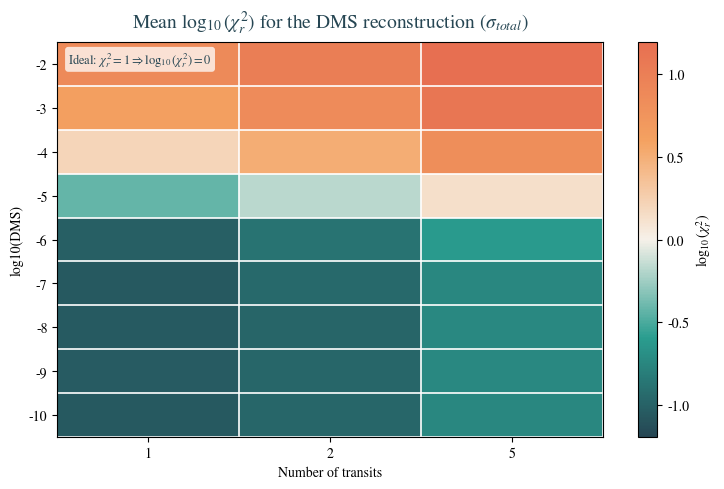

In [33]:
mean_log10_heat = (
    nplus1_results_df.groupby(["atm DMS", "n_transits"], as_index=False)["log10_chi2r_recon_vs_true"]
    .mean()
    .pivot(index="atm DMS", columns="n_transits", values="log10_chi2r_recon_vs_true")
    .reindex(index=NPLUS1_DMS_GRID, columns=NPLUS1_TRANSITS_LIST)
)

mean_log10_values = mean_log10_heat.to_numpy(dtype=float)
mean_vmax = float(np.nanmax(np.abs(mean_log10_values)))
mean_vmax = max(mean_vmax, 0.05)
mean_norm = TwoSlopeNorm(vmin=-mean_vmax, vcenter=0.0, vmax=mean_vmax)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
fig.patch.set_facecolor("white")
im = ax.imshow(
    mean_log10_values,
    aspect="auto",
    origin="lower",
    cmap=chi_div_cmap,
    norm=mean_norm,
)
ax.set_facecolor(plot_palette["cream"])
ax.set_xticks(np.arange(len(NPLUS1_TRANSITS_LIST)))
ax.set_xticklabels([str(v) for v in NPLUS1_TRANSITS_LIST])
ax.set_yticks(np.arange(len(NPLUS1_DMS_GRID)))
ax.set_yticklabels([f"{v:.0f}" for v in NPLUS1_DMS_GRID])
ax.set_xlabel("Number of transits")
ax.set_ylabel("log10(DMS)")
ax.set_title(r"Mean $\log_{10}(\chi^2_r)$ for the DMS reconstruction ($\sigma_{total}$)", color=plot_palette["deep"])
ax.set_xticks(np.arange(-0.5, len(NPLUS1_TRANSITS_LIST), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(NPLUS1_DMS_GRID), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate the interpretation of the ideal value directly on the plot.
ax.text(
    0.02,
    0.98,
    r"Ideal: $\chi^2_r = 1 \Rightarrow \log_{10}(\chi^2_r)=0$",
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="none"),
    color=plot_palette["deep"],
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\log_{10}(\chi^2_r)$")
plt.tight_layout()
plt.show()


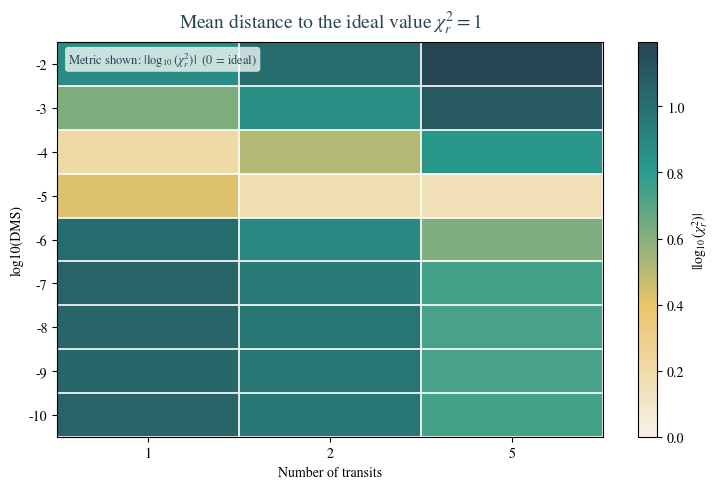

In [34]:
mean_distance_heat = (
    nplus1_results_df.groupby(["atm DMS", "n_transits"], as_index=False)["abs_log10_distance_to_ideal"]
    .mean()
    .pivot(index="atm DMS", columns="n_transits", values="abs_log10_distance_to_ideal")
    .reindex(index=NPLUS1_DMS_GRID, columns=NPLUS1_TRANSITS_LIST)
)

mean_distance_values = mean_distance_heat.to_numpy(dtype=float)
distance_vmax = float(np.nanmax(mean_distance_values))
distance_vmax = max(distance_vmax, 0.02)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
fig.patch.set_facecolor("white")
im = ax.imshow(
    mean_distance_values,
    aspect="auto",
    origin="lower",
    cmap=ideal_seq_cmap,
    vmin=0.0,
    vmax=distance_vmax,
)
ax.set_facecolor(plot_palette["cream"])
ax.set_xticks(np.arange(len(NPLUS1_TRANSITS_LIST)))
ax.set_xticklabels([str(v) for v in NPLUS1_TRANSITS_LIST])
ax.set_yticks(np.arange(len(NPLUS1_DMS_GRID)))
ax.set_yticklabels([f"{v:.0f}" for v in NPLUS1_DMS_GRID])
ax.set_xlabel("Number of transits")
ax.set_ylabel("log10(DMS)")
ax.set_title(r"Mean distance to the ideal value $\chi^2_r = 1$", color=plot_palette["deep"])
ax.set_xticks(np.arange(-0.5, len(NPLUS1_TRANSITS_LIST), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(NPLUS1_DMS_GRID), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.text(
    0.02,
    0.98,
    r"Metric shown: $|\log_{10}(\chi^2_r)|$  (0 = ideal)",
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="none"),
    color=plot_palette["deep"],
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|\log_{10}(\chi^2_r)|$")
plt.tight_layout()
plt.show()


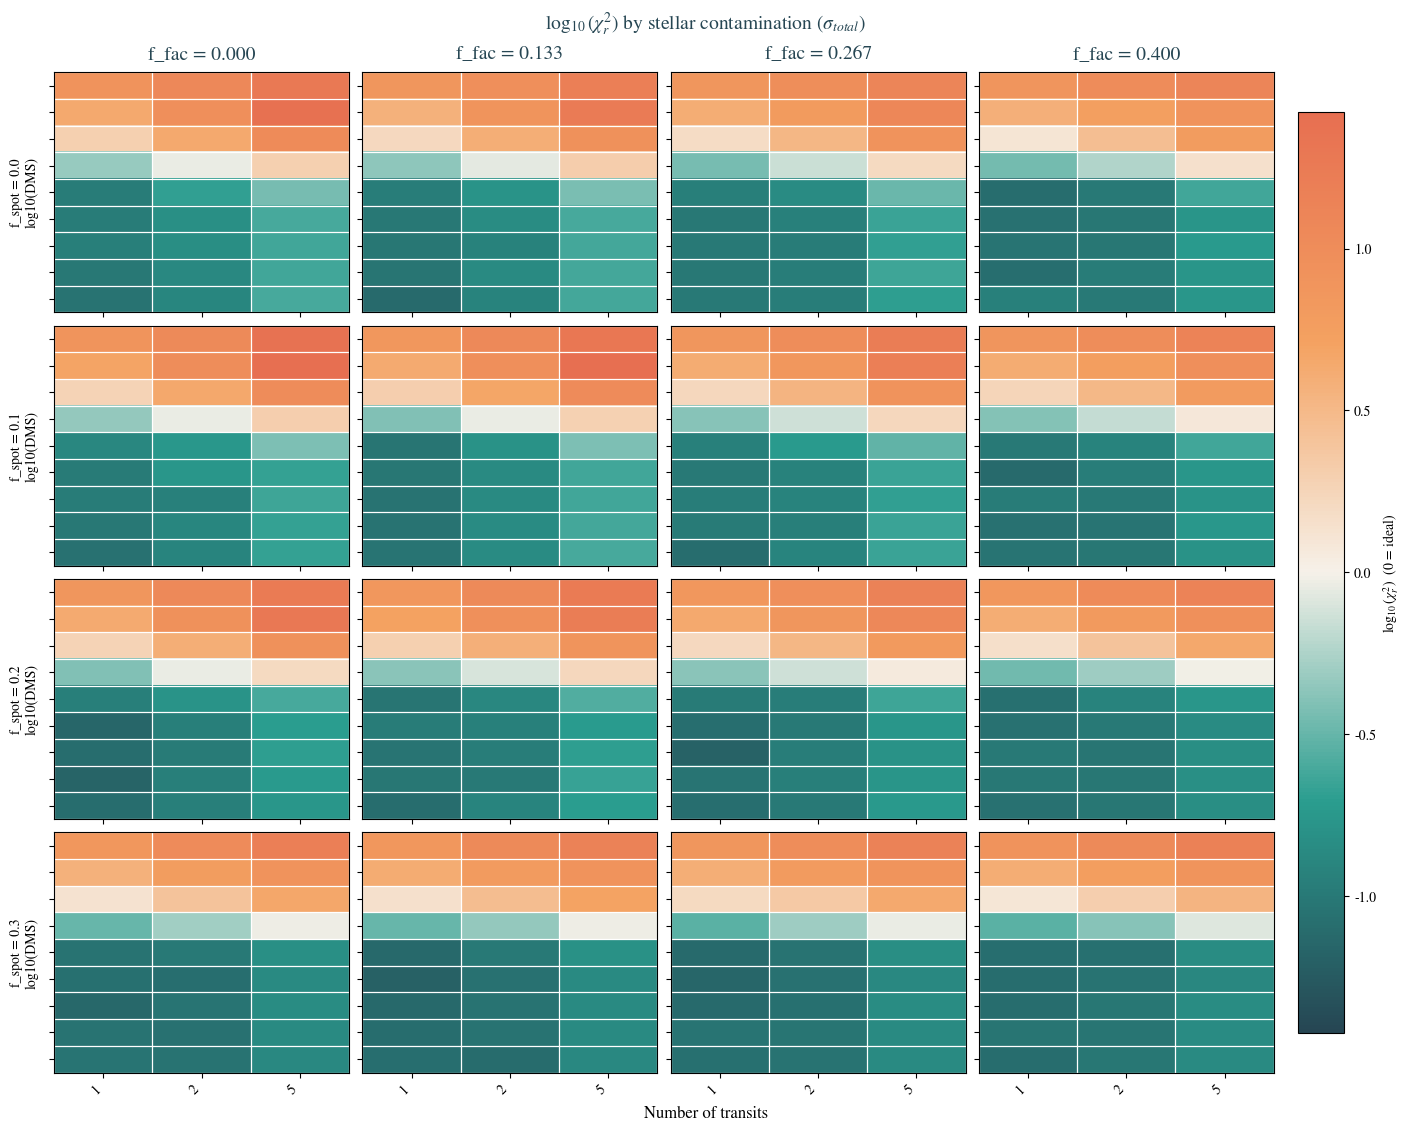

In [35]:
f_spot_values = np.sort(pd.to_numeric(nplus1_results_df["f_spot"], errors="coerce").dropna().unique())
f_fac_values = np.sort(pd.to_numeric(nplus1_results_df["f_fac"], errors="coerce").dropna().unique())
spot_col = pd.to_numeric(nplus1_results_df["f_spot"], errors="coerce").to_numpy(dtype=float)
fac_col = pd.to_numeric(nplus1_results_df["f_fac"], errors="coerce").to_numpy(dtype=float)
all_log10_values = pd.to_numeric(
    nplus1_results_df["log10_chi2r_recon_vs_true"],
    errors="coerce",
).to_numpy(dtype=float)
all_log10_values = all_log10_values[np.isfinite(all_log10_values)]
grid_vmax = max(float(np.max(np.abs(all_log10_values))), 0.05)
grid_norm = TwoSlopeNorm(vmin=-grid_vmax, vcenter=0.0, vmax=grid_vmax)

fig, axes = plt.subplots(
    len(f_spot_values),
    len(f_fac_values),
    figsize=(3.5 * len(f_fac_values), 2.8 * len(f_spot_values)),
    sharex=True,
    sharey=True,
    squeeze=False,
    constrained_layout=True,
)
fig.patch.set_facecolor("white")

im = None
for i, f_spot in enumerate(f_spot_values):
    for j, f_fac in enumerate(f_fac_values):
        ax = axes[i, j]
        mask = np.isclose(spot_col, float(f_spot)) & np.isclose(fac_col, float(f_fac))
        heat = (
            nplus1_results_df.loc[mask]
            .pivot(index="atm DMS", columns="n_transits", values="log10_chi2r_recon_vs_true")
            .reindex(index=NPLUS1_DMS_GRID, columns=NPLUS1_TRANSITS_LIST)
        )
        im = ax.imshow(
            heat.to_numpy(dtype=float),
            aspect="auto",
            origin="lower",
            cmap=chi_div_cmap,
            norm=grid_norm,
        )
        ax.set_facecolor(plot_palette["cream"])
        ax.set_xticks(np.arange(-0.5, len(NPLUS1_TRANSITS_LIST), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(NPLUS1_DMS_GRID), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.9)
        ax.tick_params(which="minor", bottom=False, left=False)

        if i == 0:
            ax.set_title(f"f_fac = {f_fac:.3f}", color=plot_palette["deep"])
        if j == 0:
            ax.set_ylabel(f"f_spot = {f_spot:.1f}\nlog10(DMS)")

        ax.set_xticks(np.arange(len(NPLUS1_TRANSITS_LIST)))
        if i == len(f_spot_values) - 1:
            ax.set_xticklabels([str(v) for v in NPLUS1_TRANSITS_LIST], rotation=45, ha="right")
        else:
            ax.set_xticklabels([])

        ax.set_yticks(np.arange(len(NPLUS1_DMS_GRID)))
        if j == 0:
            ax.set_yticklabels([f"{v:.0f}" for v in NPLUS1_DMS_GRID])
        else:
            ax.set_yticklabels([])

fig.supxlabel("Number of transits")
fig.suptitle(
    r"$\log_{10}(\chi^2_r)$ by stellar contamination ($\sigma_{total}$)",
    fontsize=14,
    color=plot_palette["deep"],
)
cbar = fig.colorbar(im, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label(r"$\log_{10}(\chi^2_r)$  (0 = ideal)")
plt.show()


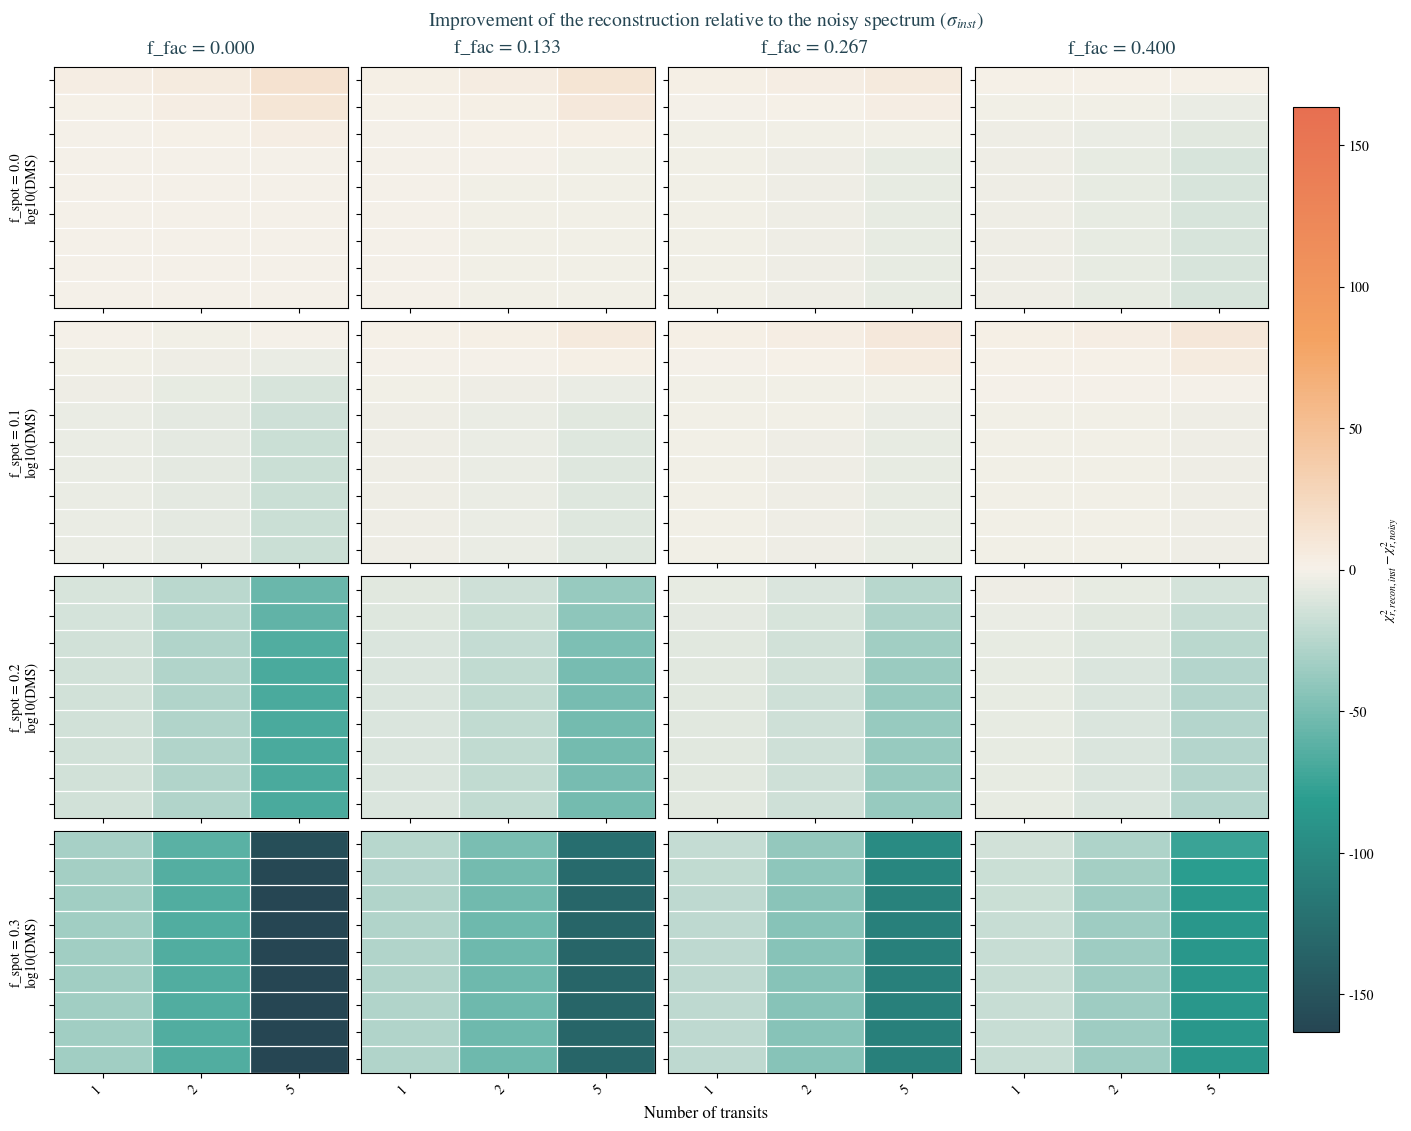

In [36]:
f_spot_values = np.sort(pd.to_numeric(nplus1_results_df["f_spot"], errors="coerce").dropna().unique())
f_fac_values = np.sort(pd.to_numeric(nplus1_results_df["f_fac"], errors="coerce").dropna().unique())
spot_col = pd.to_numeric(nplus1_results_df["f_spot"], errors="coerce").to_numpy(dtype=float)
fac_col = pd.to_numeric(nplus1_results_df["f_fac"], errors="coerce").to_numpy(dtype=float)
all_values = pd.to_numeric(nplus1_results_df["chi2r_excess_recon"], errors="coerce").to_numpy(dtype=float)
all_values = all_values[np.isfinite(all_values)]
vmax = max(float(np.max(np.abs(all_values))), 1e-3)
excess_norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, axes = plt.subplots(
    len(f_spot_values),
    len(f_fac_values),
    figsize=(3.5 * len(f_fac_values), 2.8 * len(f_spot_values)),
    sharex=True,
    sharey=True,
    squeeze=False,
    constrained_layout=True,
)
fig.patch.set_facecolor("white")

im = None
for i, f_spot in enumerate(f_spot_values):
    for j, f_fac in enumerate(f_fac_values):
        ax = axes[i, j]
        mask = np.isclose(spot_col, float(f_spot)) & np.isclose(fac_col, float(f_fac))
        heat = (
            nplus1_results_df.loc[mask]
            .pivot(index="atm DMS", columns="n_transits", values="chi2r_excess_recon")
            .reindex(index=NPLUS1_DMS_GRID, columns=NPLUS1_TRANSITS_LIST)
        )
        im = ax.imshow(
            heat.to_numpy(dtype=float),
            aspect="auto",
            origin="lower",
            cmap=chi_div_cmap,
            norm=excess_norm,
        )
        ax.set_facecolor(plot_palette["cream"])
        ax.set_xticks(np.arange(-0.5, len(NPLUS1_TRANSITS_LIST), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(NPLUS1_DMS_GRID), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.9)
        ax.tick_params(which="minor", bottom=False, left=False)

        if i == 0:
            ax.set_title(f"f_fac = {f_fac:.3f}", color=plot_palette["deep"])
        if j == 0:
            ax.set_ylabel(f"f_spot = {f_spot:.1f}\nlog10(DMS)")

        ax.set_xticks(np.arange(len(NPLUS1_TRANSITS_LIST)))
        if i == len(f_spot_values) - 1:
            ax.set_xticklabels([str(v) for v in NPLUS1_TRANSITS_LIST], rotation=45, ha="right")
        else:
            ax.set_xticklabels([])

        ax.set_yticks(np.arange(len(NPLUS1_DMS_GRID)))
        if j == 0:
            ax.set_yticklabels([f"{v:.0f}" for v in NPLUS1_DMS_GRID])
        else:
            ax.set_yticklabels([])

fig.supxlabel("Number of transits")
fig.suptitle(
    r"Improvement of the reconstruction relative to the noisy spectrum ($\sigma_{inst}$)",
    fontsize=14,
    color=plot_palette["deep"],
)
cbar = fig.colorbar(im, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label(r"$\chi^2_{r, recon, inst} - \chi^2_{r, noisy}$")
plt.show()


## Step 4 - Three concrete reconstruction examples for `DMS = -5`

The maps are useful for global trends, but it is still important to see actual spectra.

In the next figure we fix:

- `DMS = -5`
- one representative transit count
- three stellar-contamination regimes

and we compare, for each regime:

- the **clean planetary spectrum**,
- one **contaminated noisy observation** with instrumental uncertainties,
- the **reconstructed mean** from MC Dropout,
- the **total uncertainty band** around the reconstruction,
- the residuals with respect to the clean planetary spectrum.

This makes it easier to judge visually whether the reconstruction really tracks the clean reference spectrum and whether the uncertainty band is reasonable.


C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:22: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  clean_case_df.data = clean_case_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:23: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  clean_case_df.params = clean_case_df.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:31: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  noisy_case_df.data = noisy_case_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:32: UserWarning: Pandas doesn't allow columns to be created via a new attr

MC Dropout: N=1, D=385, batches=1, batch_size=32
  batch 1/1 done
MC Dropout: N=1, D=385, batches=1, batch_size=32


C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:22: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  clean_case_df.data = clean_case_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:23: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  clean_case_df.params = clean_case_df.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:31: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  noisy_case_df.data = noisy_case_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:32: UserWarning: Pandas doesn't allow columns to be created via a new attr

  batch 1/1 done
MC Dropout: N=1, D=385, batches=1, batch_size=32


C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:22: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  clean_case_df.data = clean_case_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:23: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  clean_case_df.params = clean_case_df.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:31: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  noisy_case_df.data = noisy_case_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:32: UserWarning: Pandas doesn't allow columns to be created via a new attr

  batch 1/1 done


C:\Users\User\AppData\Local\Temp\ipykernel_43332\2986900656.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.965])


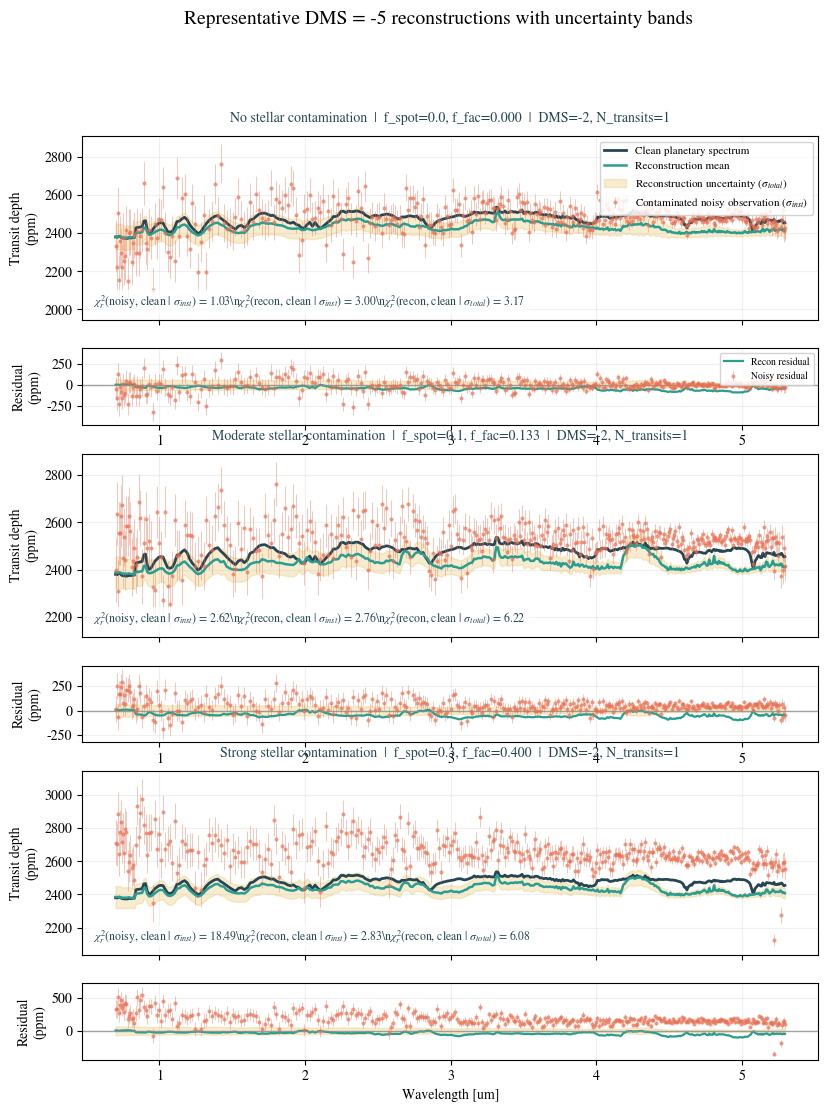

In [40]:
EXAMPLE_DMS = -2.0
EXAMPLE_TRANSITS = 1
EXAMPLE_CASES = [
    (0.0, 0.0),
    (0.1, 0.133),
    (0.3, 0.4),
]
EXAMPLE_CASE_LABELS = [
    "No stellar contamination",
    "Moderate stellar contamination",
    "Strong stellar contamination",
]

clean_dms_col = pd.to_numeric(dms_clean_df["atm DMS"], errors="coerce").to_numpy(dtype=float)
contam_spot_col = pd.to_numeric(dms_contam["f_spot"], errors="coerce").to_numpy(dtype=float)
contam_fac_col = pd.to_numeric(dms_contam["f_fac"], errors="coerce").to_numpy(dtype=float)
contam_dms_col = pd.to_numeric(dms_contam["atm DMS"], errors="coerce").to_numpy(dtype=float)

example_results = []
for (f_spot, f_fac), label in zip(EXAMPLE_CASES, EXAMPLE_CASE_LABELS):
    clean_case_df = dms_clean_df.loc[np.isclose(clean_dms_col, EXAMPLE_DMS)].copy()
    clean_case_df.data = clean_case_df.iloc[:, -n_points:]
    clean_case_df.params = clean_case_df.iloc[:, :-n_points]

    noisy_mask = (
        np.isclose(contam_spot_col, f_spot)
        & np.isclose(contam_fac_col, f_fac)
        & np.isclose(contam_dms_col, EXAMPLE_DMS)
    )
    noisy_case_df = dms_contam.loc[noisy_mask].copy()
    noisy_case_df.data = noisy_case_df.iloc[:, -n_points:]
    noisy_case_df.params = noisy_case_df.iloc[:, :-n_points]

    clean_case = generate_df_with_noise_std(
        df=clean_case_df,
        n_repeat=1,
        noise_std=0.0,
    )
    sigma_inst = sigma_by_transit[EXAMPLE_TRANSITS]
    noisy_case = generate_df_with_noise_std(
        df=noisy_case_df,
        n_repeat=1,
        noise_std=sigma_inst,
    )

    clean_case_values = clean_case.data.to_numpy(dtype=np.float32)
    noisy_case_values = noisy_case.data.to_numpy(dtype=np.float32)

    sigma_ale_example = calc_aleatoric_half_instrumental(
        sigma_inst=sigma_inst,
        shape=clean_case_values.shape,
    )
    recon_mean_example, sigma_epi_example = mc_dropout_sigma_anchor_clean(
        autoencoder_model=autoencoder,
        x_noisy_raw=noisy_case.data,
        x_clean_raw=clean_case.data,
        t_passes=T_PASSES_DROPOUT,
        batch_size=32,
    )
    sigma_total_example = combine_uncertainties(
        sigma_ale_example,
        sigma_epi_example,
        floor=EPS_SIGMA,
    )

    chi2r_noisy_example = chi2_reduced(
        clean_case_values,
        noisy_case_values,
        sigma_inst,
        p=0,
    )[0]
    chi2r_recon_example_inst = chi2_reduced(
        clean_case_values,
        recon_mean_example,
        sigma_inst,
        p=0,
    )[0]
    chi2r_recon_example_total = chi2_reduced(
        clean_case_values,
        recon_mean_example,
        sigma_total_example,
        p=0,
    )[0]

    example_results.append(
        {
            "label": label,
            "f_spot": f_spot,
            "f_fac": f_fac,
            "clean": clean_case_values[0],
            "noisy": noisy_case_values[0],
            "recon": recon_mean_example[0],
            "sigma_inst": sigma_inst,
            "sigma_total": sigma_total_example[0],
            "chi2r_noisy": chi2r_noisy_example,
            "chi2r_recon_inst": chi2r_recon_example_inst,
            "chi2r_recon_total": chi2r_recon_example_total,
        }
    )

waves_plot = np.asarray(waves, dtype=float)
fig = plt.figure(figsize=(9.5, 12.0))
gs = GridSpec(6, 1, height_ratios=[2.4, 1.0, 2.4, 1.0, 2.4, 1.0], hspace=0.22)

for idx, result in enumerate(example_results):
    ax_main = fig.add_subplot(gs[2 * idx])
    ax_res = fig.add_subplot(gs[2 * idx + 1], sharex=ax_main)

    clean_ppm = result["clean"][::-1] * 1e6
    noisy_ppm = result["noisy"][::-1] * 1e6
    recon_ppm = result["recon"][::-1] * 1e6
    sigma_inst_ppm = result["sigma_inst"][::-1] * 1e6
    sigma_total_ppm = result["sigma_total"][::-1] * 1e6

    ax_main.plot(
        waves_plot,
        clean_ppm,
        color=plot_palette["deep"],
        linewidth=2.0,
        label="Clean planetary spectrum",
    )
    ax_main.errorbar(
        waves_plot,
        noisy_ppm,
        yerr=sigma_inst_ppm,
        fmt="o",
        ms=2.0,
        elinewidth=0.5,
        capsize=0,
        alpha=0.55,
        color=plot_palette["red"],
        label=r"Contaminated noisy observation ($\sigma_{inst}$)",
    )
    ax_main.plot(
        waves_plot,
        recon_ppm,
        color=plot_palette["teal"],
        linewidth=1.8,
        label="Reconstruction mean",
    )
    ax_main.fill_between(
        waves_plot,
        recon_ppm - sigma_total_ppm,
        recon_ppm + sigma_total_ppm,
        color=plot_palette["gold"],
        alpha=0.32,
        label=r"Reconstruction uncertainty ($\sigma_{total}$)",
    )

    ax_main.set_ylabel("Transit depth\n(ppm)")
    ax_main.set_title(
        result["label"]
        + f"  |  f_spot={result['f_spot']:.1f}, f_fac={result['f_fac']:.3f}"
        + f"  |  DMS={EXAMPLE_DMS:.0f}, N_transits={EXAMPLE_TRANSITS}",
        fontsize=10,
        color=plot_palette["deep"],
    )
    chi_text = (
        rf"$\chi^2_r$(noisy, clean | $\sigma_{{inst}}$) = {result['chi2r_noisy']:.2f}\n"
        + rf"$\chi^2_r$(recon, clean | $\sigma_{{inst}}$) = {result['chi2r_recon_inst']:.2f}\n"
        + rf"$\chi^2_r$(recon, clean | $\sigma_{{total}}$) = {result['chi2r_recon_total']:.2f}"
    )
    ax_main.text(
        0.015,
        0.05,
        chi_text,
        transform=ax_main.transAxes,
        fontsize=8.5,
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.78, edgecolor="none"),
        color=plot_palette["deep"],
    )
    ax_main.grid(True, alpha=0.18)
    if idx == 0:
        ax_main.legend(fontsize=8, loc="upper right", framealpha=0.85)
    ax_main.tick_params(labelbottom=False)

    residual_noisy = noisy_ppm - clean_ppm
    residual_recon = recon_ppm - clean_ppm

    ax_res.fill_between(
        waves_plot,
        -sigma_total_ppm,
        sigma_total_ppm,
        color=plot_palette["gold"],
        alpha=0.32,
    )
    ax_res.errorbar(
        waves_plot,
        residual_noisy,
        yerr=sigma_inst_ppm,
        fmt="o",
        ms=2.0,
        elinewidth=0.5,
        capsize=0,
        alpha=0.55,
        color=plot_palette["red"],
        label="Noisy residual",
    )
    ax_res.plot(
        waves_plot,
        residual_recon,
        color=plot_palette["teal"],
        linewidth=1.6,
        label="Recon residual",
    )
    ax_res.axhline(0.0, color=plot_palette["gray"], linewidth=1.0, alpha=0.8)
    ax_res.set_ylabel("Residual\n(ppm)")
    ax_res.grid(True, alpha=0.18)
    if idx == 0:
        ax_res.legend(fontsize=7, loc="upper right", framealpha=0.85)

ax_res.set_xlabel("Wavelength [um]")
fig.suptitle("Representative DMS = -5 reconstructions with uncertainty bands", fontsize=14, y=0.985)
plt.tight_layout(rect=[0, 0.02, 1, 0.965])
plt.show()


## Step 5 - Simpler global summaries

The next two plots keep the end of the experiment easier to read.

- The first plot is now a heatmap: `x = N_transits`, `y = log10(DMS)`, and the color shows the **mean epistemic uncertainty**. To keep the map readable, the value is averaged over wavelength and over the stellar-contamination cases.
- The second plot still fixes `N_transits = 1` and shows the reduced chi-square as a function of `log10(DMS)`, with one line per stellar-contamination case.


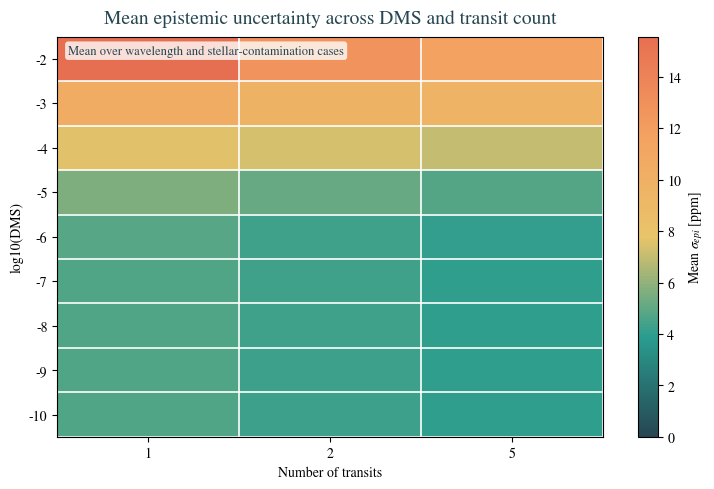

In [46]:
epi_heat_df = (
    nplus1_results_df.groupby(["atm DMS", "n_transits"], as_index=False)["sigma_epi_mean"]
    .mean()
    .sort_values(["atm DMS", "n_transits"], ignore_index=True)
)
for col in ["atm DMS", "n_transits", "sigma_epi_mean"]:
    epi_heat_df[col] = pd.to_numeric(epi_heat_df[col], errors="coerce")

epi_heat = (
    epi_heat_df
    .pivot(index="atm DMS", columns="n_transits", values="sigma_epi_mean")
    .reindex(index=NPLUS1_DMS_GRID, columns=NPLUS1_TRANSITS_LIST)
)
epi_heat_ppm = epi_heat.to_numpy(dtype=float) * 1e6
epi_cmap = LinearSegmentedColormap.from_list(
    "epi_seq",
    [plot_palette["deep"], plot_palette["teal"], plot_palette["gold"], plot_palette["sand"], plot_palette["red"]],
)

epi_vmax = float(np.nanmax(epi_heat_ppm))
epi_vmax = max(epi_vmax, 1e-6)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
fig.patch.set_facecolor("white")
im = ax.imshow(
    epi_heat_ppm,
    aspect="auto",
    origin="lower",
    cmap=epi_cmap,
    vmin=0.0,
    vmax=epi_vmax,
)
ax.set_facecolor(plot_palette["cream"])
ax.set_xticks(np.arange(len(NPLUS1_TRANSITS_LIST)))
ax.set_xticklabels([str(v) for v in NPLUS1_TRANSITS_LIST])
ax.set_yticks(np.arange(len(NPLUS1_DMS_GRID)))
ax.set_yticklabels([f"{v:.0f}" for v in NPLUS1_DMS_GRID])
ax.set_xlabel("Number of transits")
ax.set_ylabel("log10(DMS)")
ax.set_title("Mean epistemic uncertainty across DMS and transit count", color=plot_palette["deep"])
ax.set_xticks(np.arange(-0.5, len(NPLUS1_TRANSITS_LIST), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(NPLUS1_DMS_GRID), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.text(
    0.02,
    0.98,
    "Mean over wavelength and stellar-contamination cases",
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.78, edgecolor="none"),
    color=plot_palette["deep"],
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Mean $\sigma_{epi}$ [ppm]")
plt.tight_layout()
plt.show()


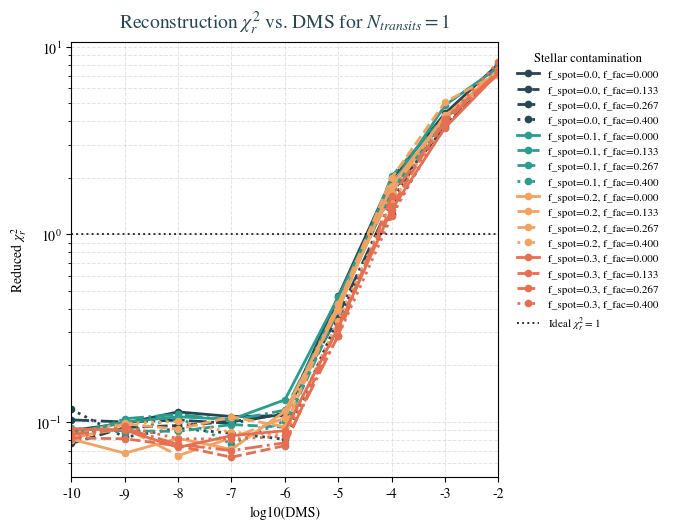

In [43]:
CHI2_FIXED_TRANSITS = 1
spot_values = np.sort(pd.to_numeric(nplus1_results_df["f_spot"], errors="coerce").dropna().unique())
fac_values = np.sort(pd.to_numeric(nplus1_results_df["f_fac"], errors="coerce").dropna().unique())
spot_colors = [plot_palette["deep"], plot_palette["teal"], plot_palette["sand"], plot_palette["red"]]
fac_styles = ["-", "--", "-.", ":"]
spot_color_map = {value: spot_colors[i % len(spot_colors)] for i, value in enumerate(spot_values)}
fac_style_map = {value: fac_styles[i % len(fac_styles)] for i, value in enumerate(fac_values)}

def contamination_label(f_spot: float, f_fac: float) -> str:
    return f"f_spot={f_spot:.1f}, f_fac={f_fac:.3f}"

chi2_lines_df = (
    nplus1_results_df[nplus1_results_df["n_transits"] == CHI2_FIXED_TRANSITS]
    .copy()
    .sort_values(["f_spot", "f_fac", "atm DMS"], ignore_index=True)
)
for col in ["f_spot", "f_fac", "atm DMS", "chi2r_recon_vs_true"]:
    chi2_lines_df[col] = pd.to_numeric(chi2_lines_df[col], errors="coerce")

chi2_spot_col = chi2_lines_df["f_spot"].to_numpy(dtype=float)
chi2_fac_col = chi2_lines_df["f_fac"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8.6, 5.4))
fig.patch.set_facecolor("white")

for row in chi2_lines_df[["f_spot", "f_fac"]].drop_duplicates().itertuples(index=False):
    f_spot = float(row.f_spot)
    f_fac = float(row.f_fac)
    mask = np.isclose(chi2_spot_col, f_spot) & np.isclose(chi2_fac_col, f_fac)
    one_case = chi2_lines_df.loc[mask].sort_values("atm DMS")

    ax.plot(
        one_case["atm DMS"].to_numpy(dtype=float),
        one_case["chi2r_recon_vs_true"].to_numpy(dtype=float),
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        color=spot_color_map[f_spot],
        linestyle=fac_style_map[f_fac],
        label=contamination_label(f_spot, f_fac),
    )

ax.axhline(1.0, color="black", linestyle=":", linewidth=1.4, alpha=0.8, label=r"Ideal $\chi^2_r = 1$")
ax.set_yscale("log")
ax.set_xticks(NPLUS1_DMS_GRID)
ax.set_xlim(NPLUS1_DMS_GRID[0], NPLUS1_DMS_GRID[-1])
ax.set_xlabel("log10(DMS)")
ax.set_ylabel(r"Reduced $\chi^2_r$")
ax.set_title(r"Reconstruction $\chi^2_r$ vs. DMS for $N_{transits}=1$", color=plot_palette["deep"])
ax.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.35)
ax.legend(
    title="Stellar contamination",
    fontsize=8,
    title_fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()


<>:31: DeprecationWarning: invalid escape sequence \p
<>:31: DeprecationWarning: invalid escape sequence \p
C:\Users\User\AppData\Local\Temp\ipykernel_43332\1356517648.py:31: DeprecationWarning: invalid escape sequence \p
  label="$\pm 1\sigma$"


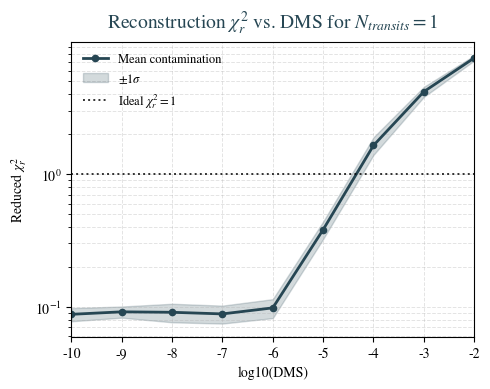

In [49]:
chi2_lines_unified = (
    nplus1_results_df[nplus1_results_df["n_transits"] == CHI2_FIXED_TRANSITS]
    .copy()
)

for col in ["atm DMS", "chi2r_recon_vs_true"]:
    chi2_lines_unified[col] = pd.to_numeric(chi2_lines_unified[col], errors="coerce")

unified_stats = chi2_lines_unified.groupby("atm DMS")["chi2r_recon_vs_true"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor("white")

ax.plot(
    unified_stats["atm DMS"].to_numpy(dtype=float),
    unified_stats["mean"].to_numpy(dtype=float),
    marker="o",
    markersize=4.5,
    linewidth=2.0,
    color=plot_palette["deep"],
    linestyle="-",
    label="Mean contamination",
)

ax.fill_between(
    unified_stats["atm DMS"].to_numpy(dtype=float),
    (unified_stats["mean"] - unified_stats["std"]).to_numpy(dtype=float),
    (unified_stats["mean"] + unified_stats["std"]).to_numpy(dtype=float),
    color=plot_palette["deep"],
    alpha=0.2,
    label="$\pm 1\sigma$"
)

ax.axhline(1.0, color="black", linestyle=":", linewidth=1.4, alpha=0.8, label=r"Ideal $\chi^2_r = 1$")
ax.set_yscale("log")
ax.set_xticks(NPLUS1_DMS_GRID)
ax.set_xlim(NPLUS1_DMS_GRID[0], NPLUS1_DMS_GRID[-1])
ax.set_xlabel("log10(DMS)")
ax.set_ylabel(r"Reduced $\chi^2_r$")
ax.set_title(r"Reconstruction $\chi^2_r$ vs. DMS for $N_{transits}=1$", color=plot_palette["deep"])
ax.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.35)
ax.legend(
    fontsize=9,
    loc="best",
    frameon=False,
)
plt.tight_layout()
plt.show()